# Lakshya

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [35]:
df = pd.read_csv("/home/lakki/Documents/brisbane-green-infrastructure-analysis/src/q1/suburb-silo-data.csv")
df.head()
df

,Suburb,date,latitude,longitude,daily_rain,max_temp,min_temp,vp,vp_deficit,radiation,rh_tmax,et_morton_potential,et_morton_actual,evap_morton_lake,et_morton_wet,evap_comb,evap_syn
0,ACACIA RIDGE,2016-01-01,-27.5854,153.0236,0.0,30.1,17.2,15.7,19.7,24.8,36.8,8.6,3.6,6.2,6.1,8.1,7.1
1,ACACIA RIDGE,2016-01-02,-27.5854,153.0236,0.0,30.2,15.7,15.0,19.8,27.9,35.0,9.0,4.3,6.9,6.7,7.8,7.6
2,ACACIA RIDGE,2016-01-03,-27.5854,153.0236,0.0,27.2,20.1,18.9,13.6,11.7,52.4,5.4,1.4,3.5,3.4,3.1,4.2
3,ACACIA RIDGE,2016-01-04,-27.5854,153.0236,7.9,27.6,18.1,20.2,11.9,13.4,54.7,5.0,2.7,3.9,3.9,3.7,4.3
4,ACACIA RIDGE,2016-01-05,-27.5854,153.0236,36.1,25.5,20.4,23.5,6.7,3.9,72.0,1.8,0.8,1.3,1.3,1.6,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711007,ZILLMERE,2026-01-27,-27.3582,153.0391,0.0,29.6,25.2,25.6,13.3,13.6,61.7,5.9,2.8,4.4,4.4,8.7,4.6
711008,ZILLMERE,2026-01-28,-27.3582,153.0391,0.0,30.1,21.8,18.4,19.4,29.2,43.1,9.9,5.2,7.8,7.6,9.8,8.0
711009,ZILLMERE,2026-01-29,-27.3582,153.0391,0.0,30.2,21.4,19.7,18.1,27.6,45.9,9.2,5.2,7.4,7.2,4.9,7.6
711010,ZILLMERE,2026-01-30,-27.3582,153.0391,0.0,30.4,21.6,22.6,15.6,23.5,52.1,7.7,5.0,6.5,6.4,6.4,6.6


In [5]:
len(df["Suburb"].unique())

193

# Plot average temperature for each surburb

In [6]:
df['date'] = pd.to_datetime(df['date'])

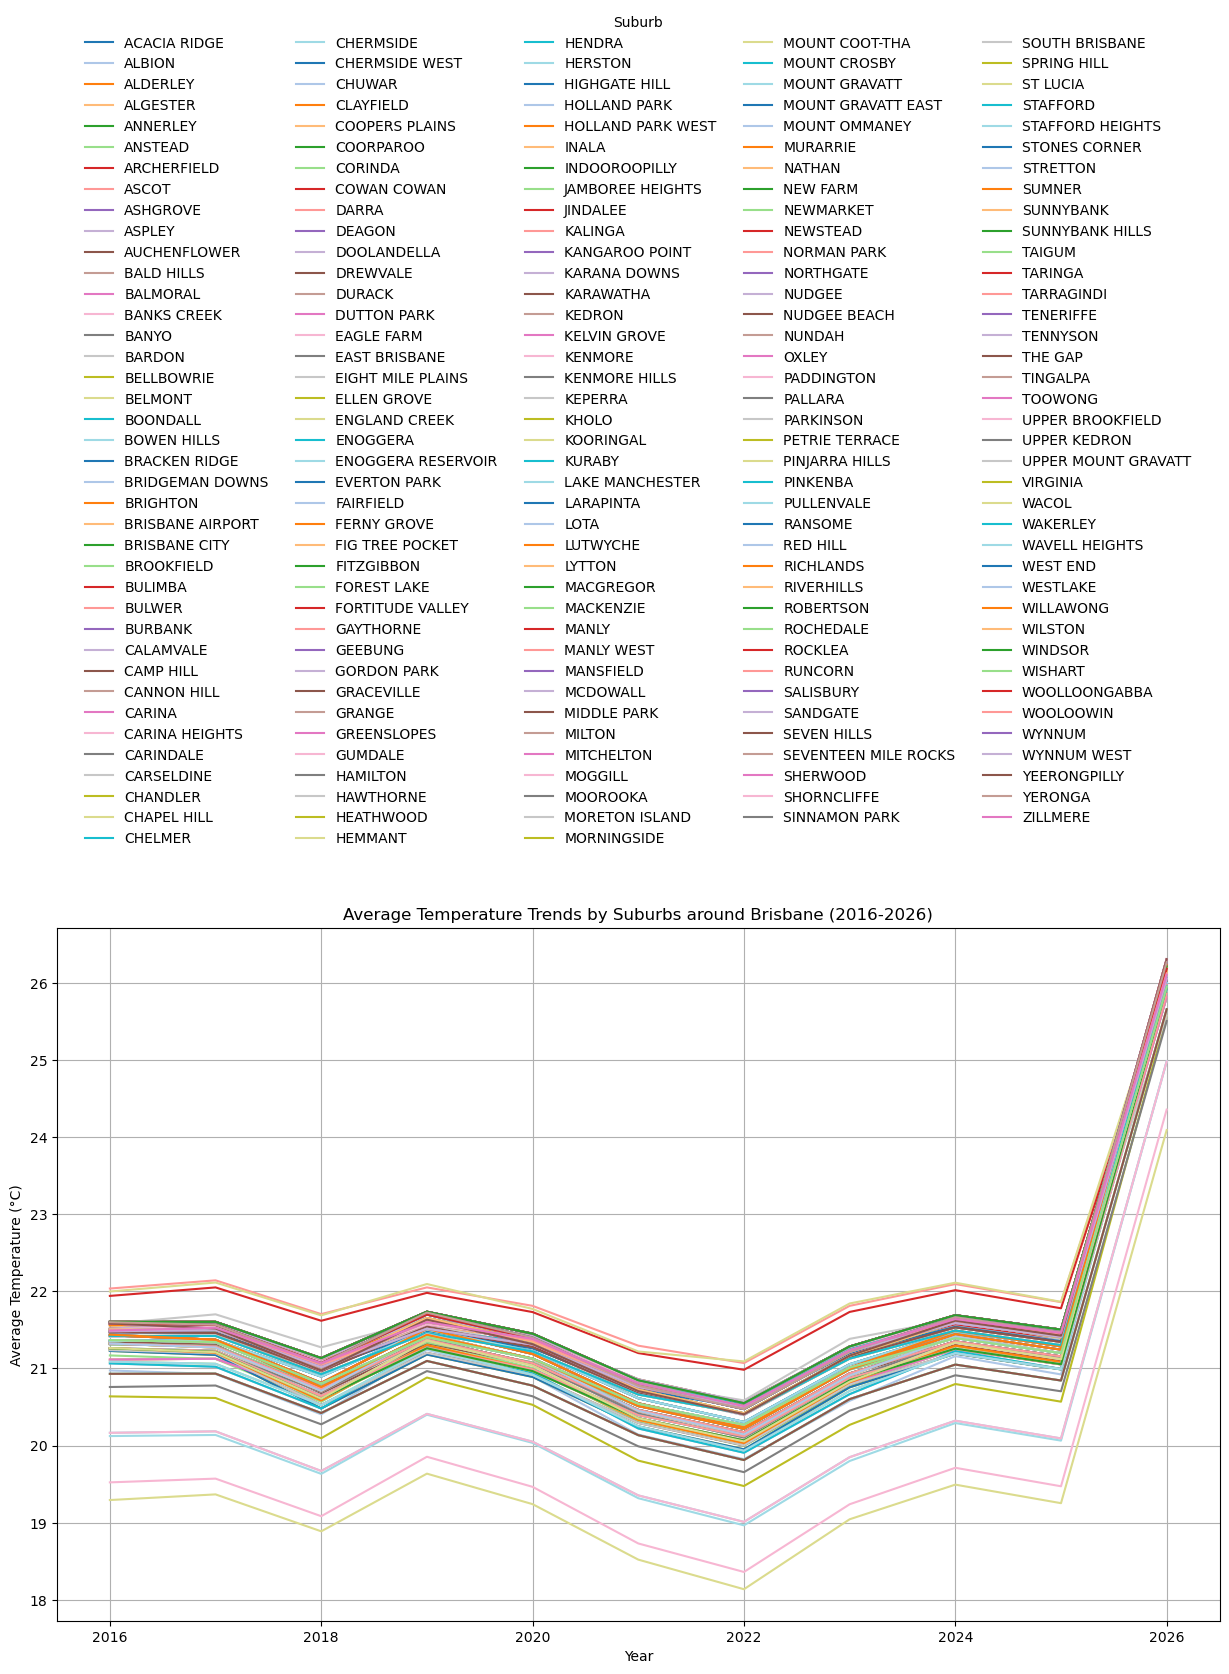

In [7]:
df['year'] = df['date'].dt.year
# df['month'] = df['date'].dt.month
df['avg_temp'] = df[['min_temp', 'max_temp']].mean(axis=1)
annual_suburb_trends = df.groupby(['Suburb', 'year'])['avg_temp'].mean().reset_index()

#Plotting
plt.figure(figsize=(15, 9))
sns.lineplot(data=annual_suburb_trends, x='year', y='avg_temp', hue='Suburb', palette='tab20')
plt.legend(title='Suburb', 
           bbox_to_anchor=(0.5, 1.1), 
           ncol=5, 
           loc="lower center",
           frameon=False)
plt.title('Average Temperature Trends by Suburbs around Brisbane (2016-2026)')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.grid(True)
plt.show()

In [ ]:
# Plotting Average temp of each suburb Annually 
# and plotting them all into a singe plot shows 
# a paralell rise and fall of annual temperature trends 
# suggesting that each year it gets warmer
# 2022 was the coldest year with avg temprature dropping to 14°C


#Plotting Average Annual temperature Graphs for each suburb allows us to identify the overall coldest and hottest suburbs each year

In [158]:
selected_suburbs = [
    # University 
    'ST LUCIA', 
    
    # Urban and Maritime Thermos
    'FORTITUDE VALLEY', 'MORETON ISLAND', 'BULWER',
    
    # Cool Sanctuaries 
    'ENGLAND CREEK', 'LAKE MANCHESTER', 'ENOGGERA RESERVOIR',

    #The Continental Heatlands 
    'CHUWAR', 'TOOWONG', 'ACACIA RIDGE', 'KHOLO',

    #Estuarine Zone
    'BRISBANE AIRPORT', 'CHANDLER', 'MACKENZIE'   
    
]

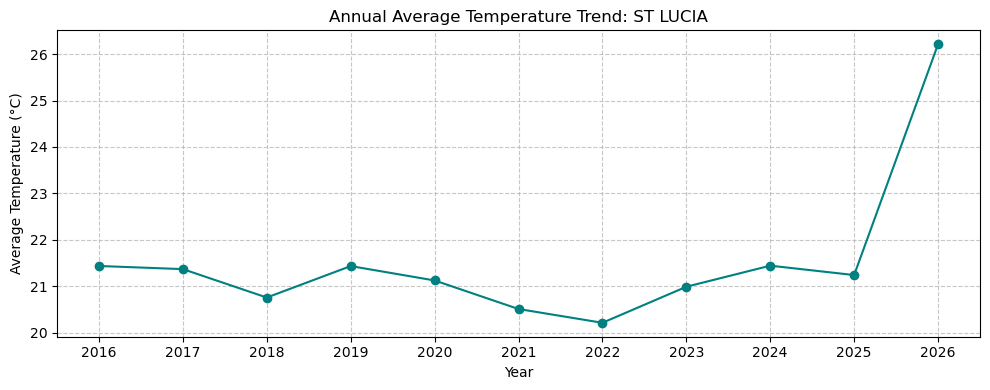

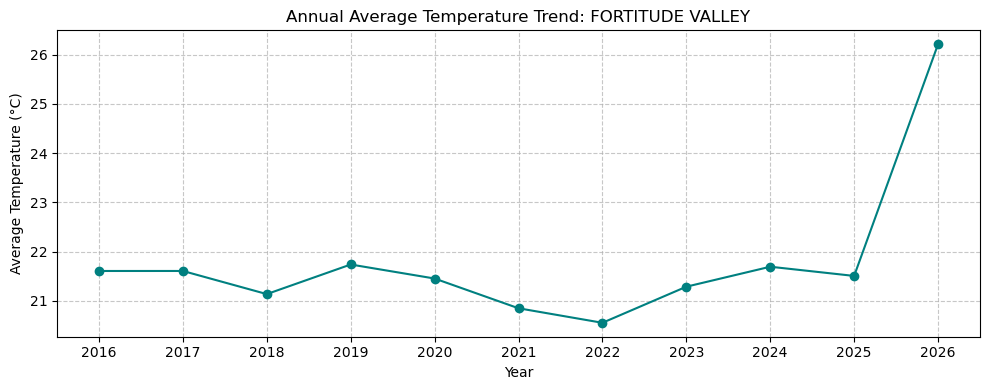

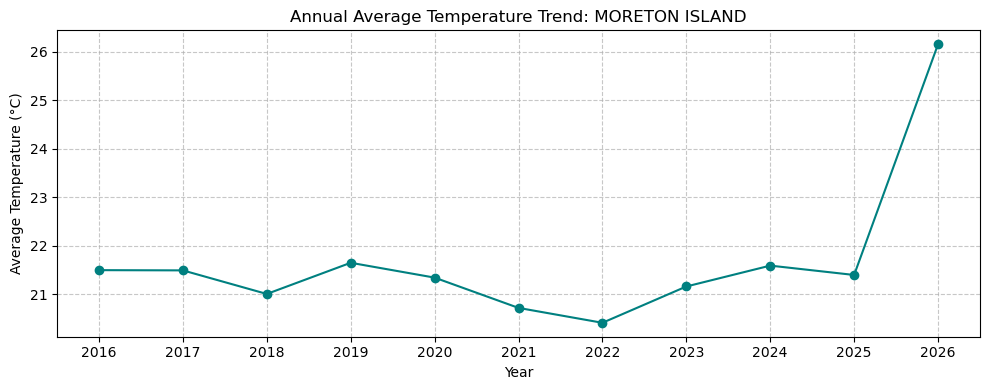

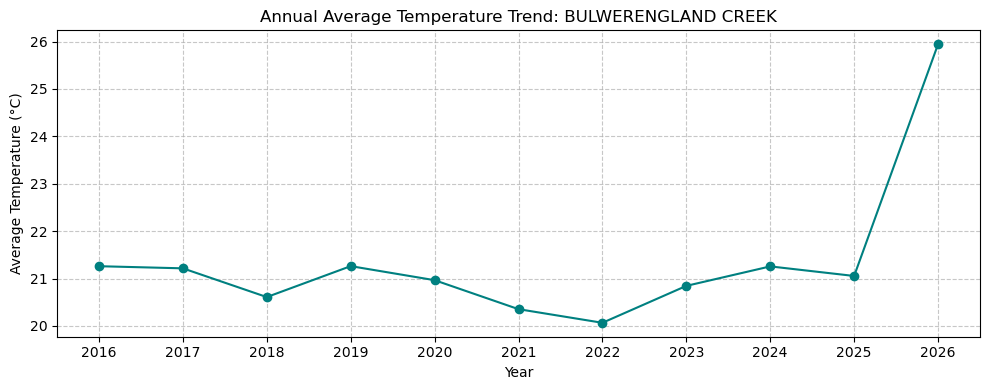

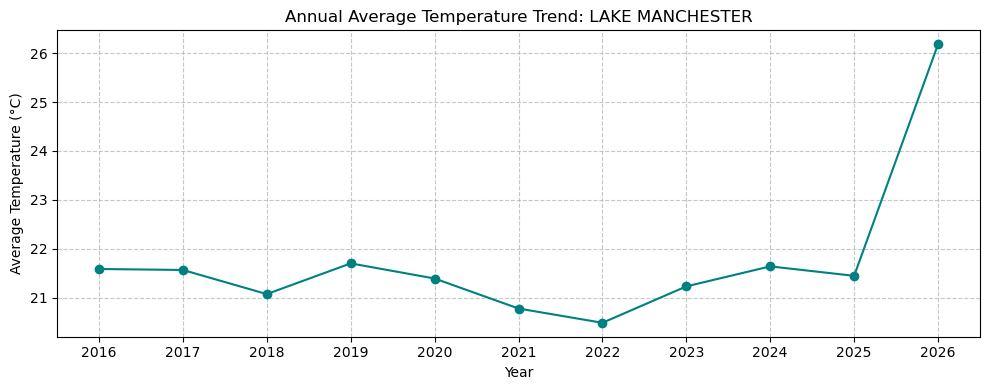

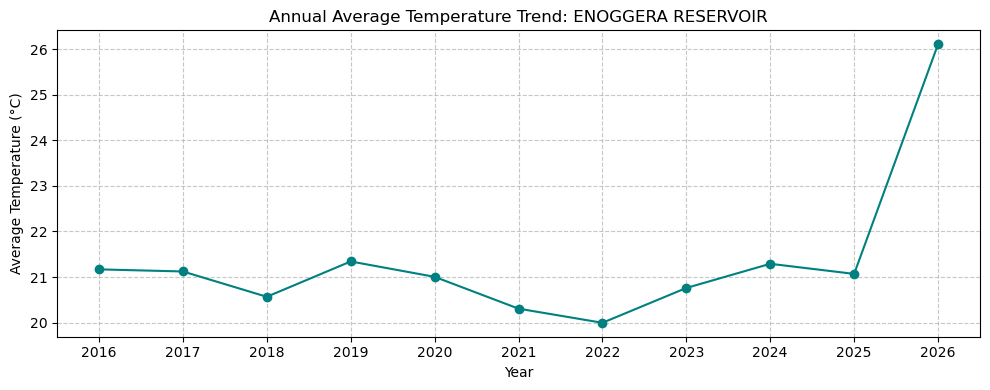

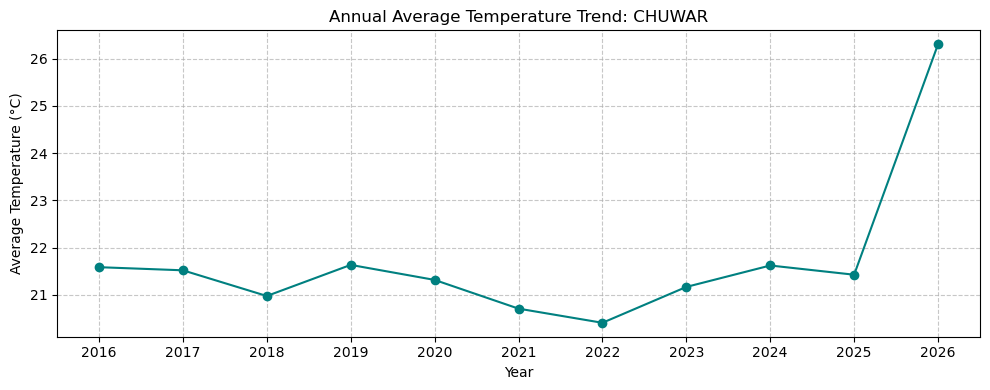

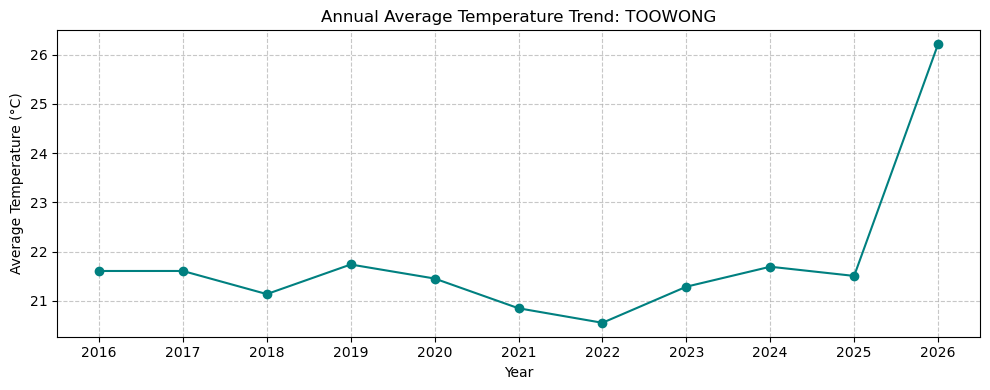

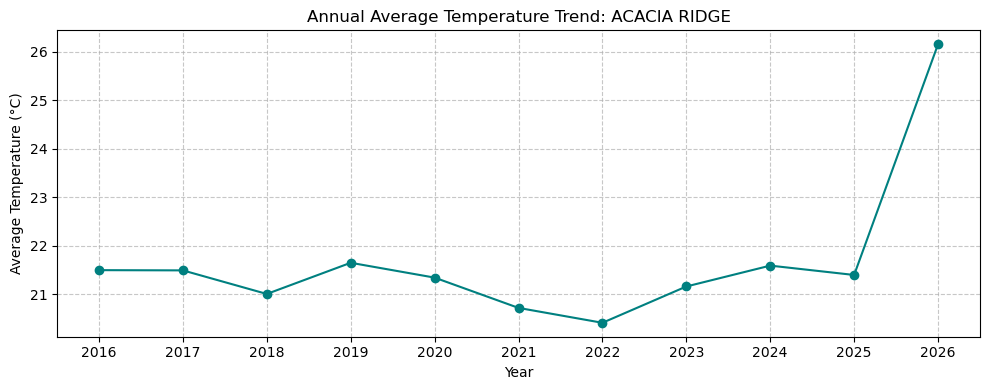

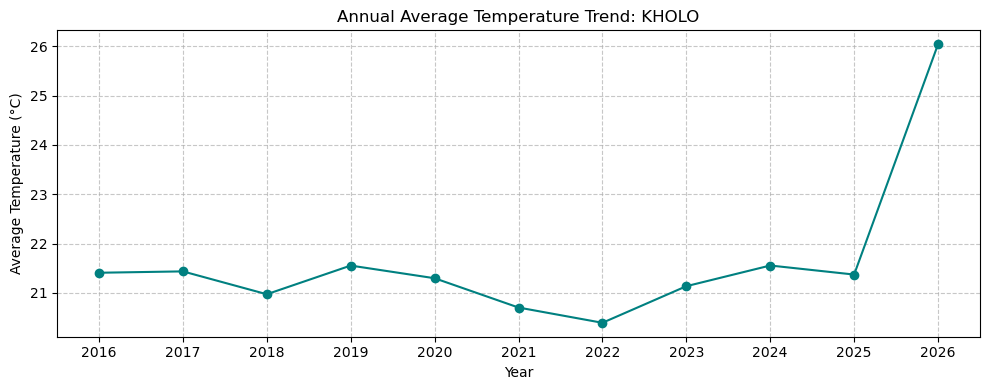

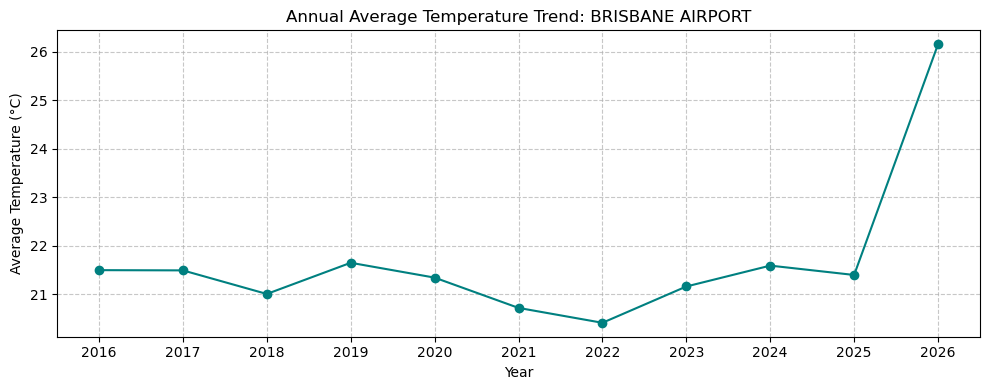

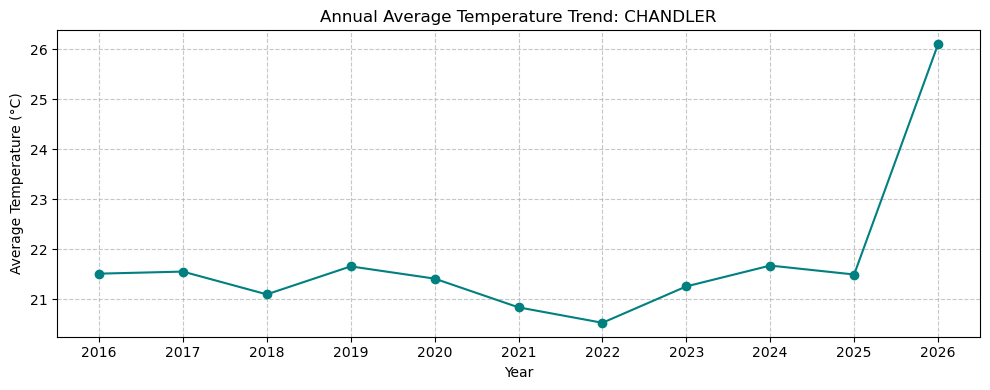

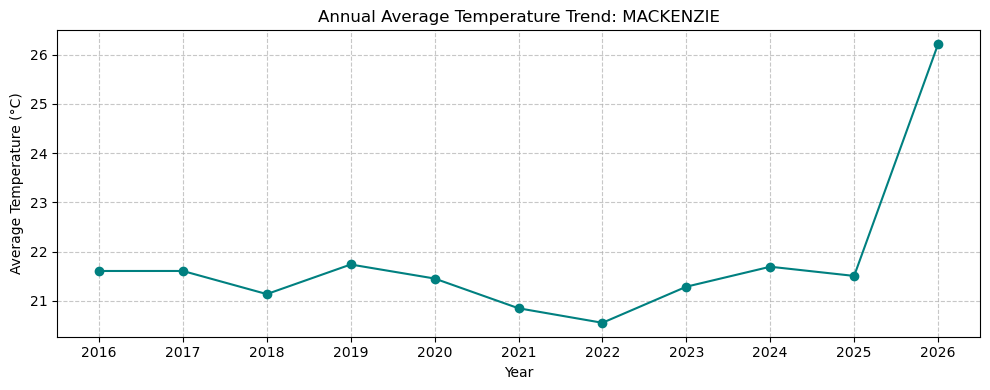

In [146]:
# suburbs = annual_suburb_trends['Suburb'].unique()
# nested_list = [
#     annual_suburb_trends[annual_suburb_trends['Suburb'] == s]['avg_temp'].tolist() 
#     for s in suburbs
# ]

years = annual_suburb_trends['year'].unique()

for i, suburb_name in enumerate(selected_suburbs):
    plt.figure(figsize=(10, 4))
    
    # Plot the specificly for indexed suburb
    plt.plot(years, nested_list[i], marker='o', linestyle='-', color='teal')
    
    plt.title(f'Annual Average Temperature Trend: {suburb_name}')
    plt.xlabel('Year')
    plt.ylabel('Average Temperature (°C)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(years) 
    
    plt.tight_layout()
    plt.show()

In [ ]:
## The reason for sudden rise in 2026 is due to the fact that we do not have data for winter 2026 to balance 

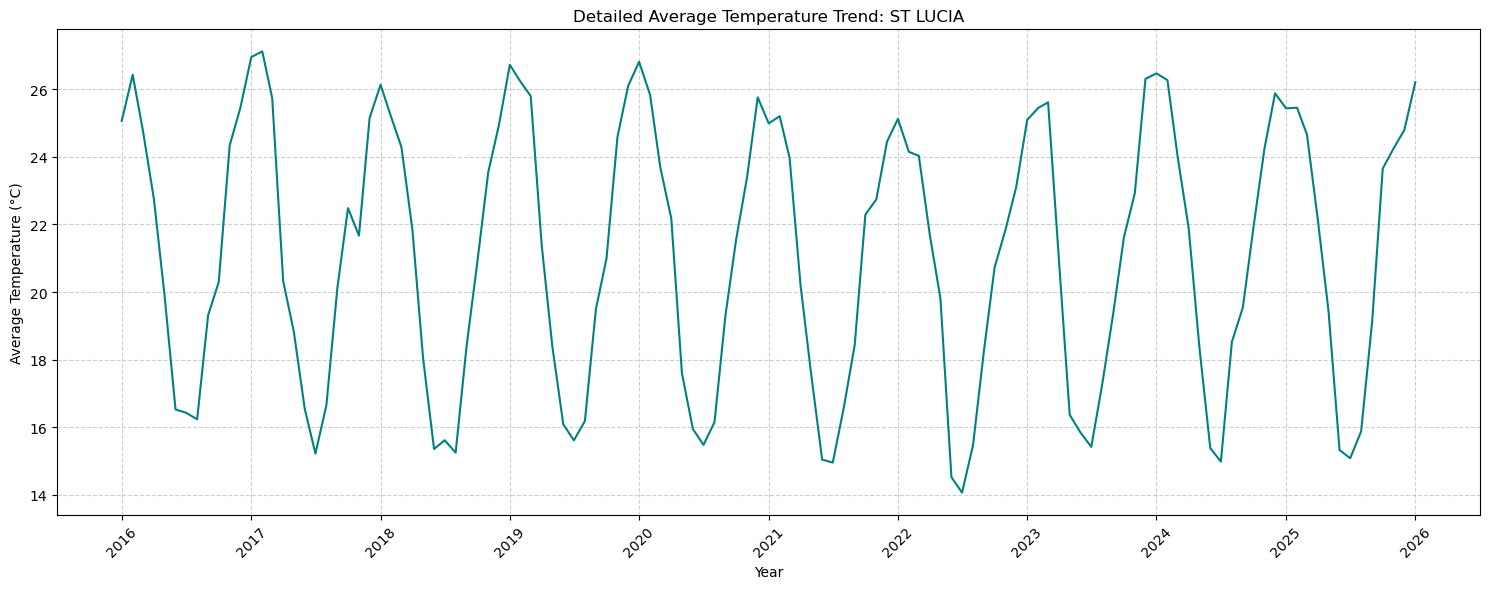

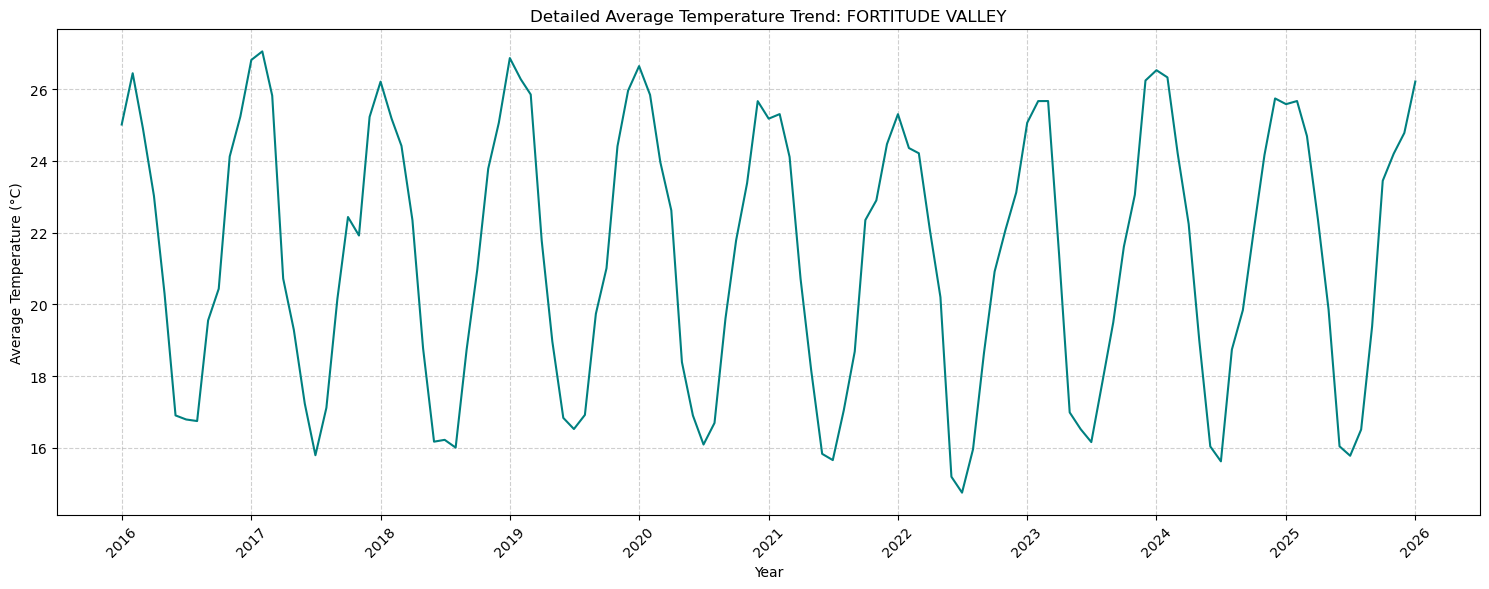

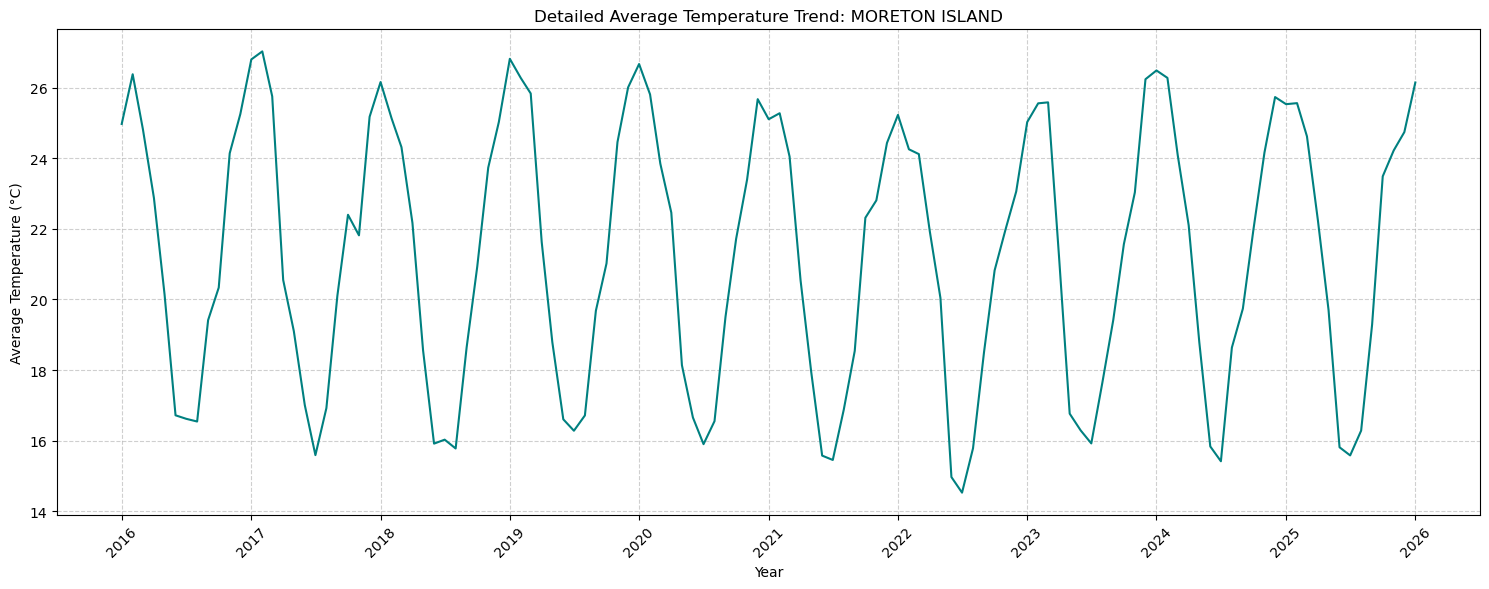

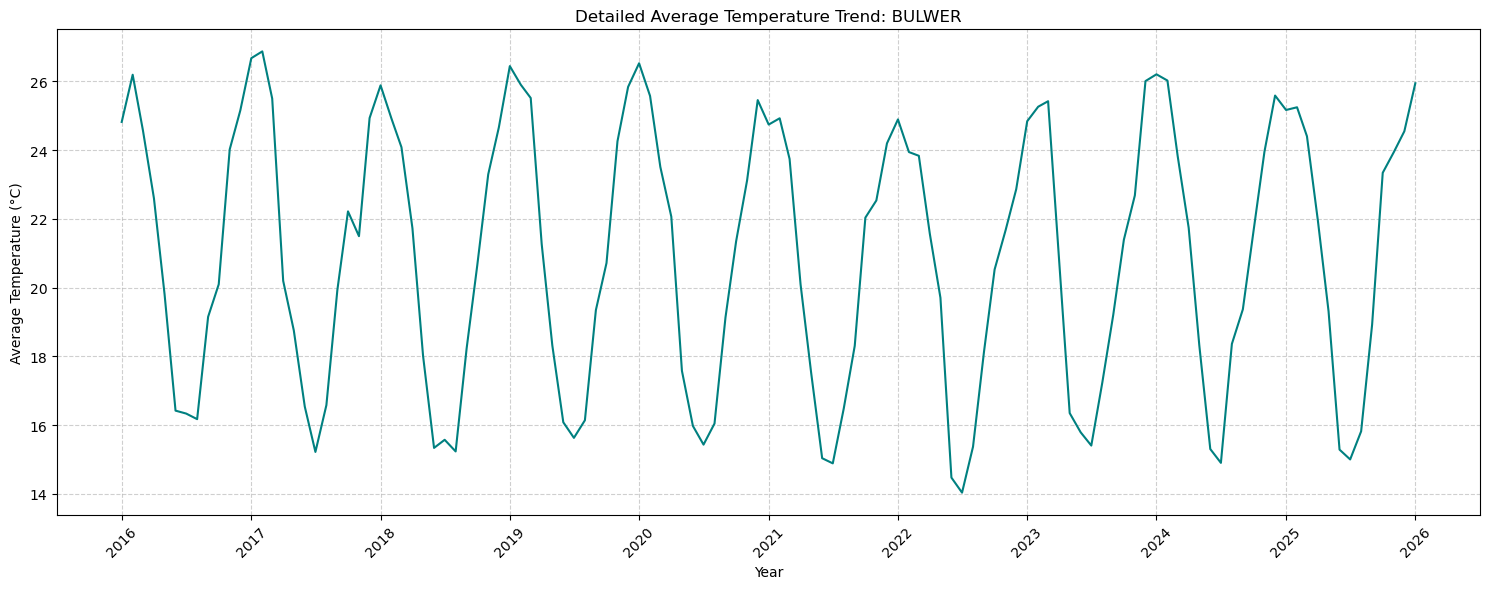

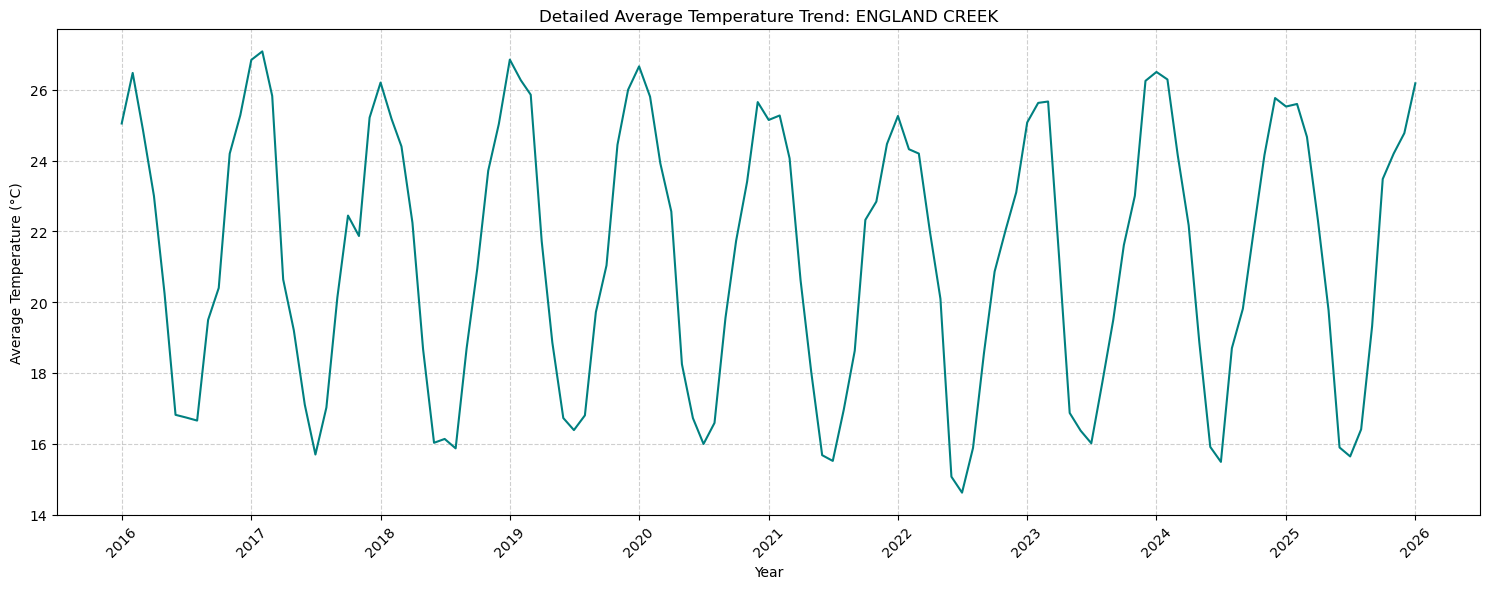

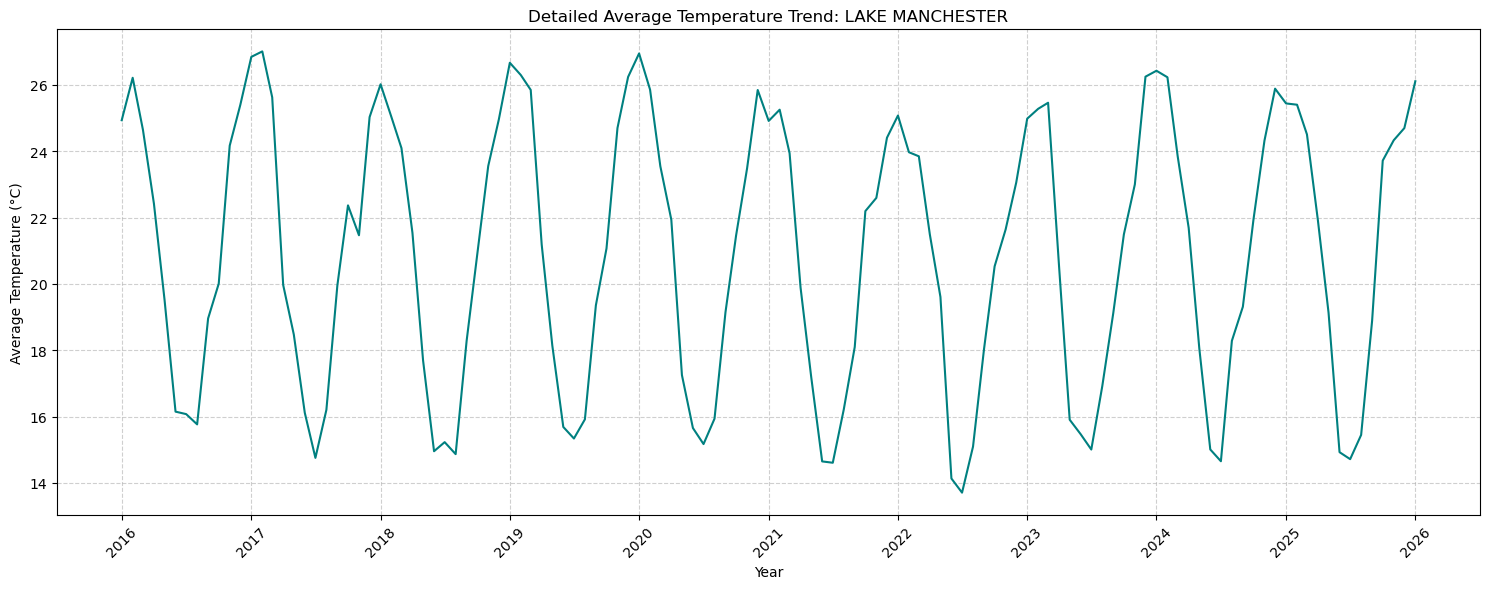

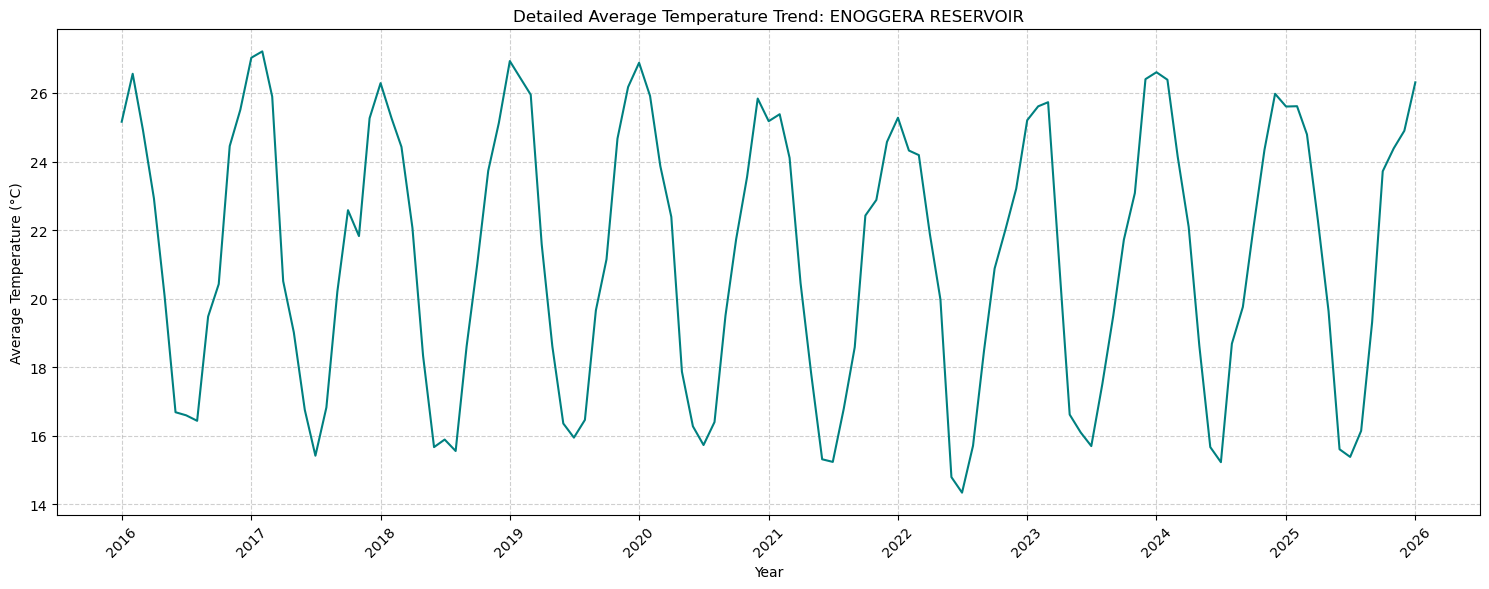

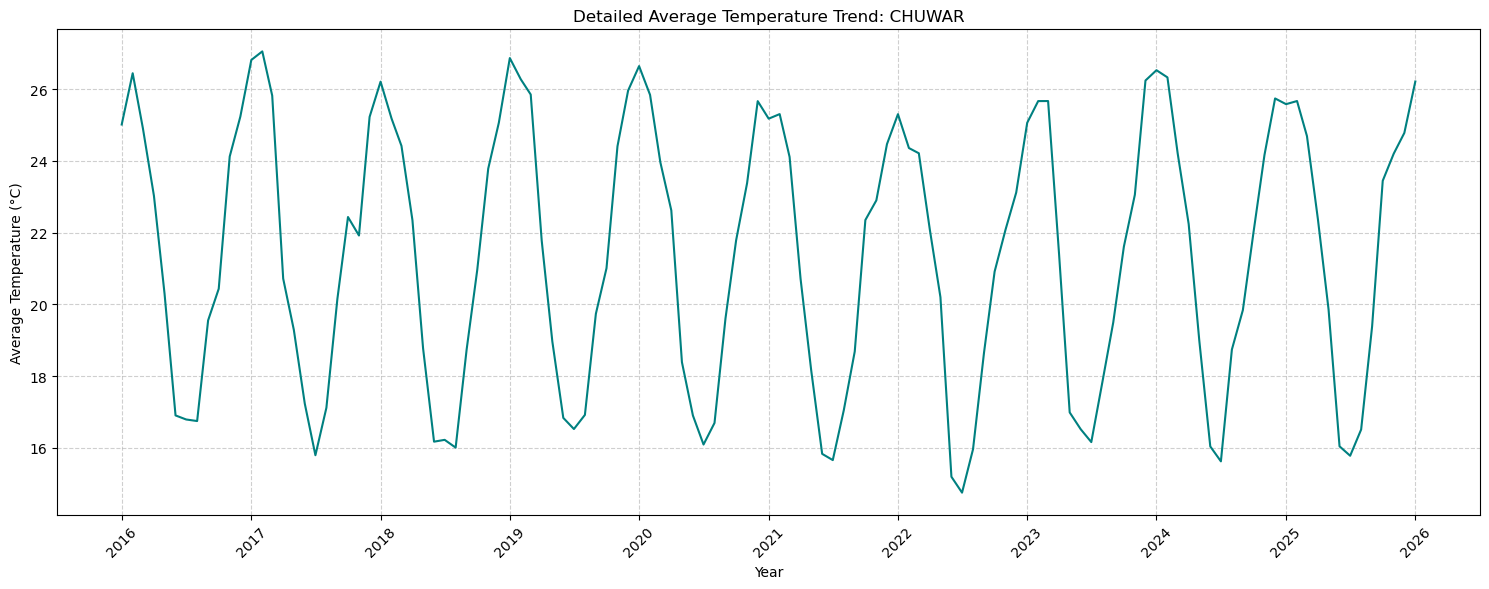

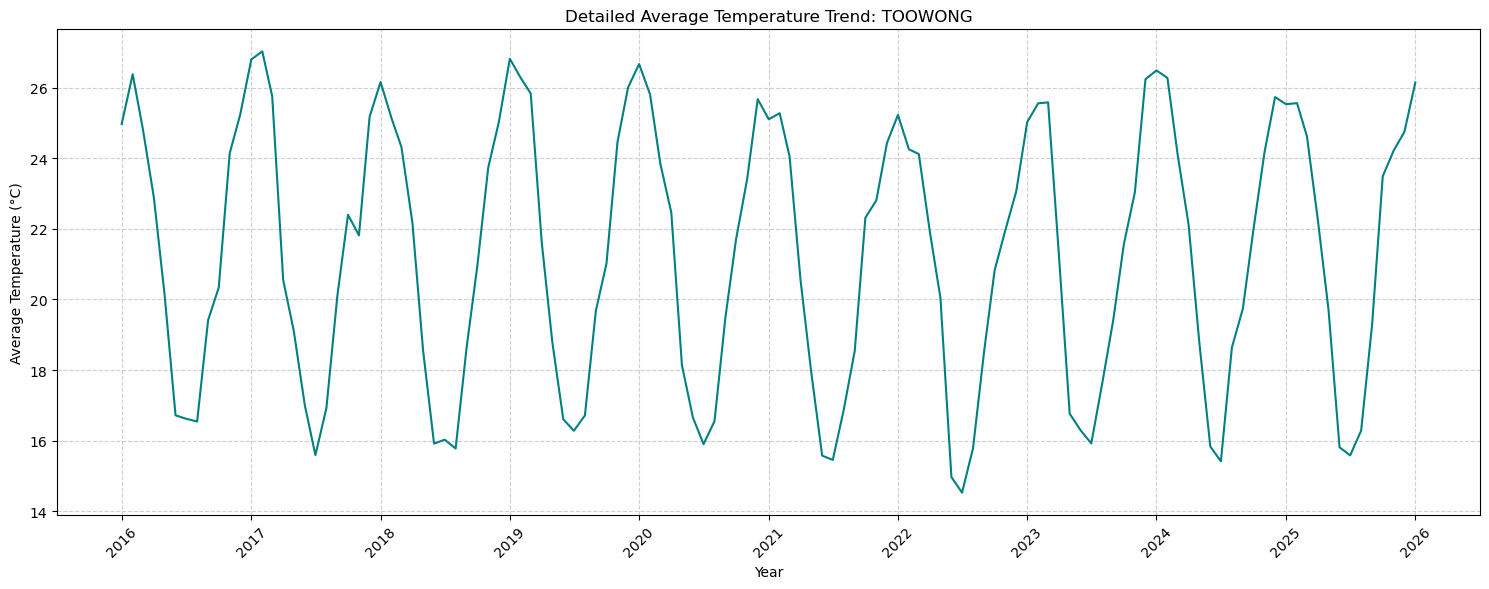

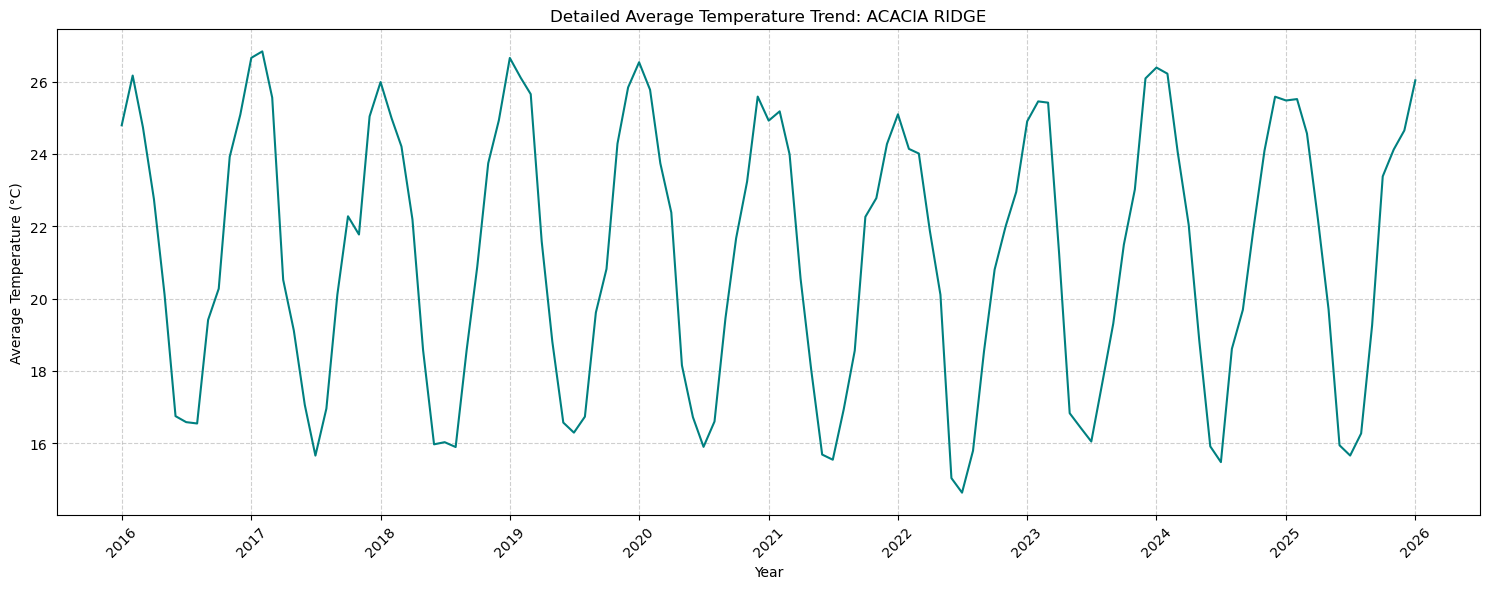

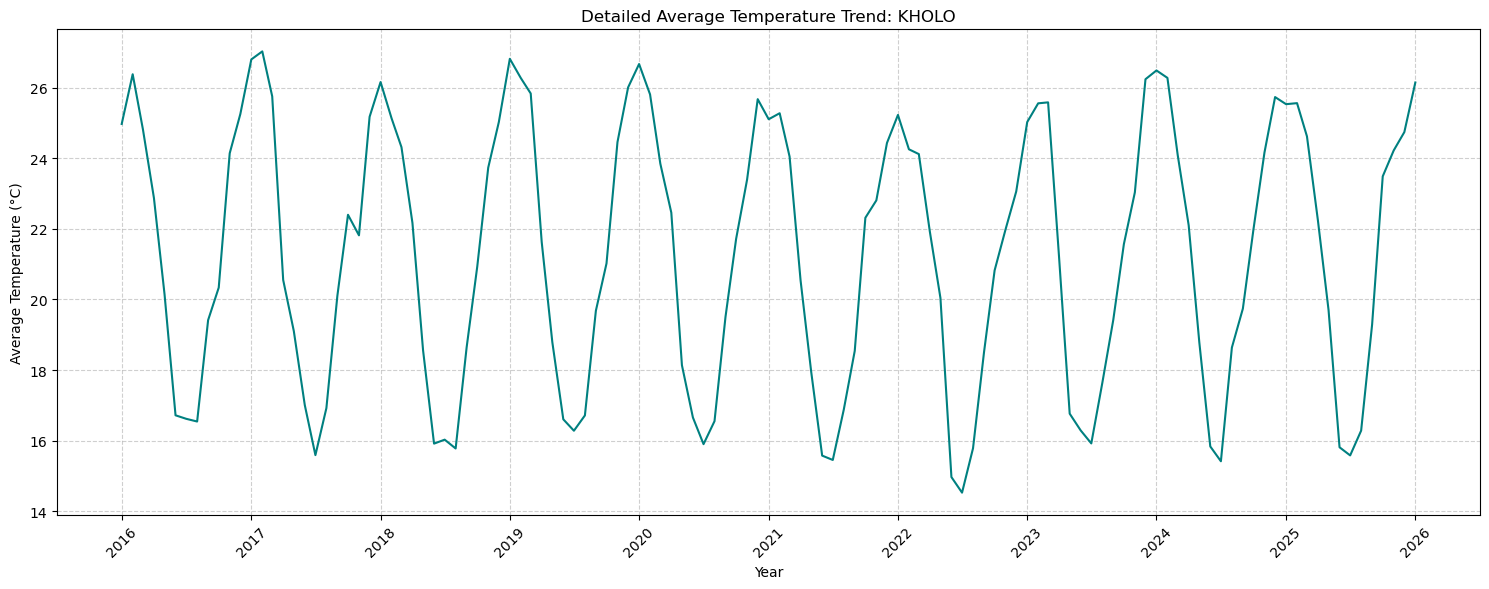

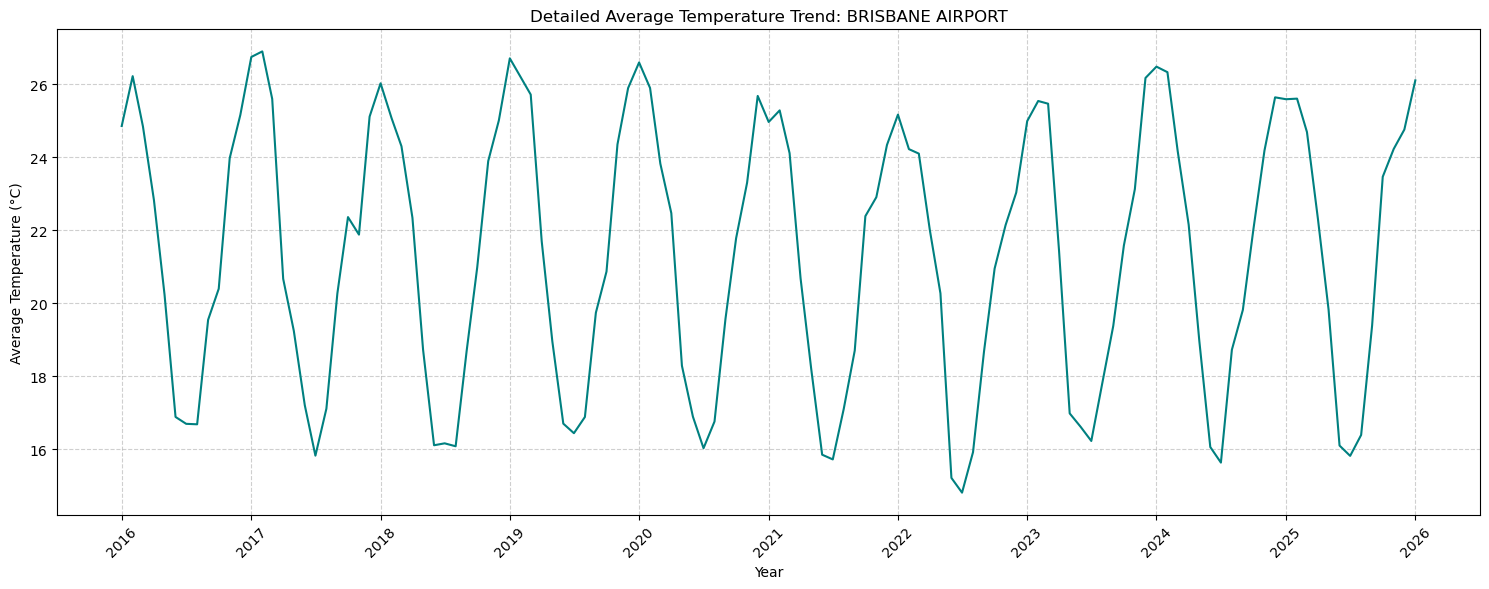

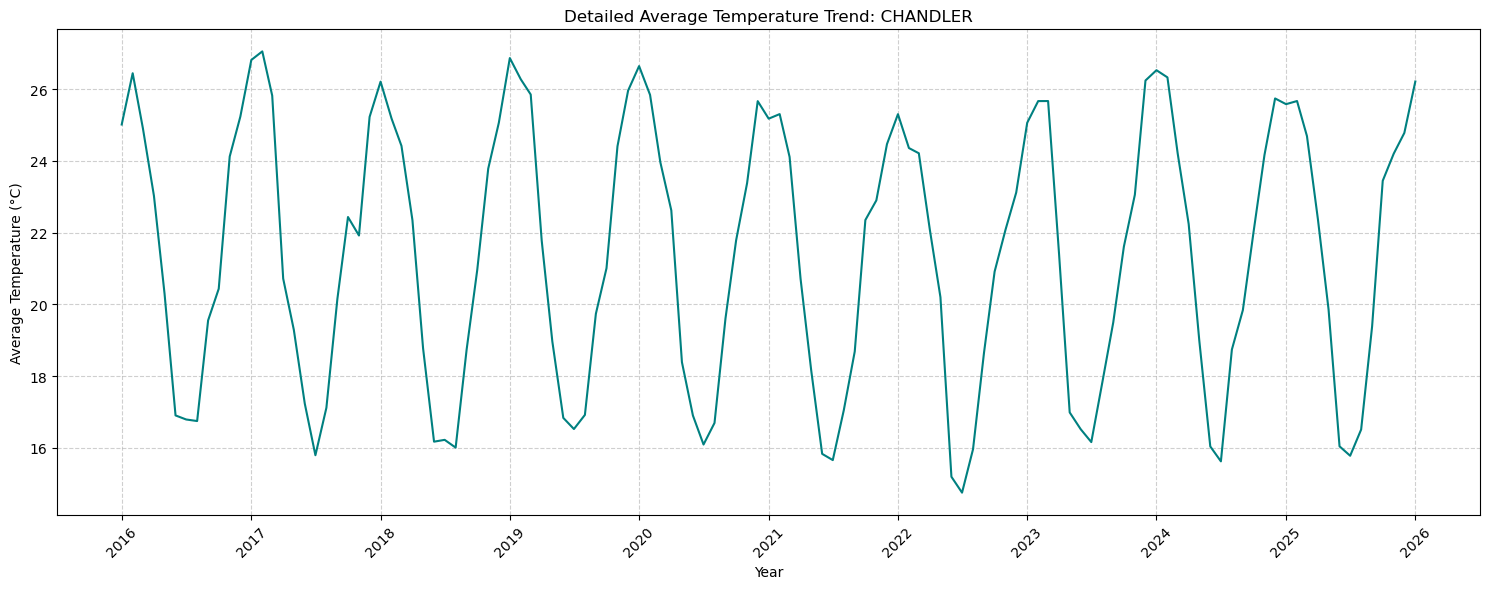

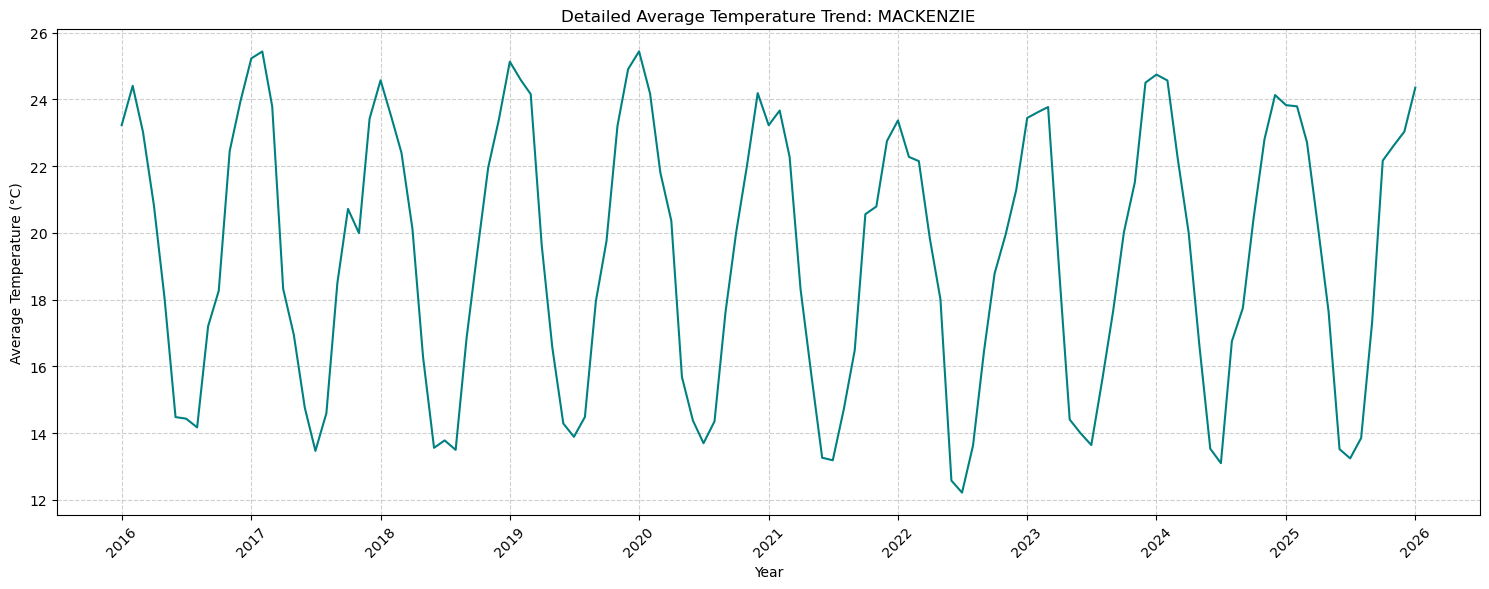

In [159]:
# We calculate the monthly average for each suburb
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

monthly_suburb_trends = df.groupby(['Suburb', 'year', 'month'])['avg_temp'].mean().reset_index()

# Create a 'Year-Month' datetime column for the x-axis
monthly_suburb_trends['year_month'] = pd.to_datetime(
    monthly_suburb_trends[['year', 'month']].assign(day=1)
)

monthly_suburb_trends = monthly_suburb_trends.sort_values(['Suburb', 'year_month'])

suburbs = monthly_suburb_trends['Suburb'].unique()
nested_list = [
    monthly_suburb_trends[monthly_suburb_trends['Suburb'] == s]['avg_temp'].tolist() 
    for s in suburbs
]

all_dates = sorted(monthly_suburb_trends['year_month'].unique())

# Plotting
for i, suburb_name in enumerate(selected_suburbs):
    plt.figure(figsize=(15, 6))
    
    plt.plot(all_dates, nested_list[i], marker=None, linestyle='-', color='teal', linewidth=1.5)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator()) 
    
    plt.title(f'Detailed Average Temperature Trend: {suburb_name}')
    plt.xlabel('Year')
    plt.ylabel('Average Temperature (°C)')

    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Plot distribution of temperature for each suburb
### select small radius / perimeter of brisbane

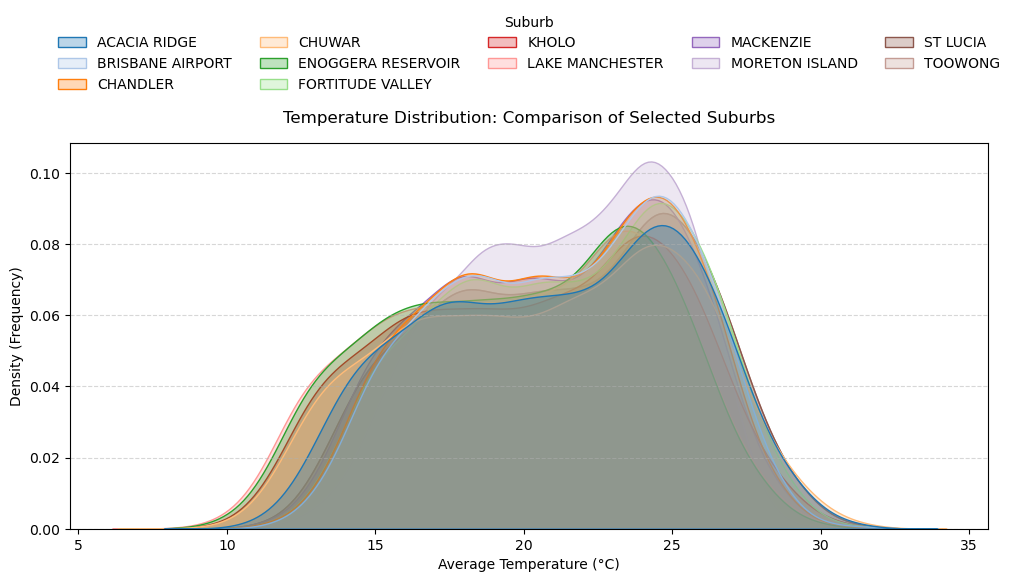

In [118]:
df_filtered = df[df['Suburb'].isin(selected_suburbs)]

# Plotting
plt.figure(figsize=(12, 6))

ax = sns.kdeplot(
    data=df_filtered, 
    x='avg_temp', 
    hue='Suburb', 
    fill=True, 
    common_norm=False, 
    palette='tab20', 
    alpha=0.3,
    legend=True 
)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, 1.1), 
    ncol=5, 
    title='Suburb', 
    frameon=False
)
plt.title('Temperature Distribution: Comparison of Selected Suburbs', pad=15)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Density (Frequency)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

# Plot correlation matrix

In [12]:
df_dropped= df.drop(columns=["date", "Suburb"])

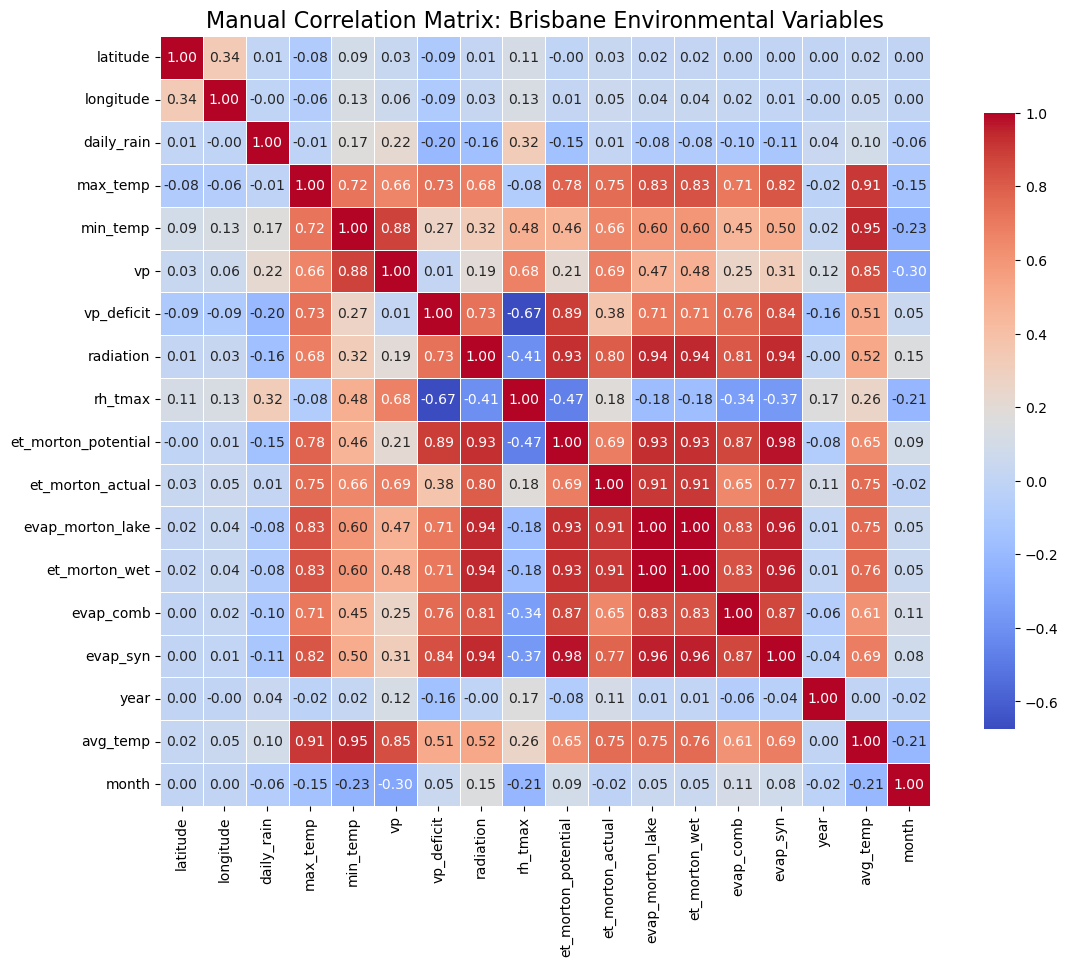

In [13]:
corr_matrix = df_dropped.corr()

# 3. Plotting the Heatmap with all  columns
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm', 
    linewidths=0.5, 
    square=True,
    cbar_kws={"shrink": .8}
)


plt.title('Manual Correlation Matrix: Brisbane Environmental Variables', size=16)
plt.show()

In [14]:
df_columns = [
'max_temp',
'min_temp',
'vp', 
'vp_deficit', 
'radiation', 
'et_morton_potential', 
'et_morton_actual', 
'evap_morton_lake', 
'et_morton_wet', 
'evap_comb', 
'evap_syn',
'avg_temp'
]


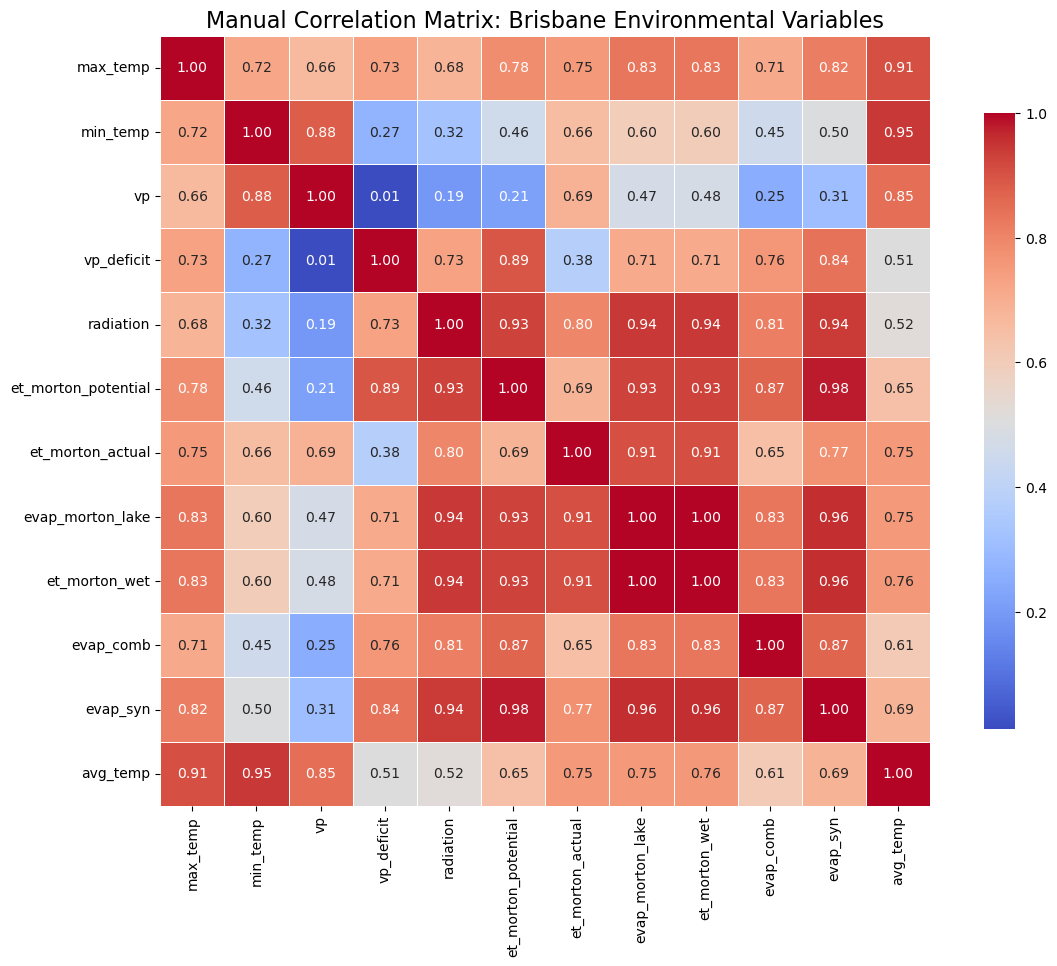

In [15]:
corr_matrix = df[df_columns].corr()

# 3. Plotting the Heatmap with filtered columns showing strong relations
plt.figure(figsize=(14, 10))

sns.heatmap(
corr_matrix, 
annot=True,          
fmt=".2f",           
cmap='coolwarm', 
linewidths=0.5, 
square=True,
cbar_kws={"shrink": .8}
)

plt.title('Manual Correlation Matrix: Brisbane Environmental Variables', size=16)
plt.show()


In [16]:
# One Hot Suburbs
df_encoded = pd.get_dummies(df, columns=['Suburb'], prefix='suburb')

print(df_encoded.head())

        date  latitude  longitude  daily_rain  max_temp  min_temp    vp  \
0 2016-01-01  -27.5854   153.0236         0.0      30.1      17.2  15.7   
1 2016-01-02  -27.5854   153.0236         0.0      30.2      15.7  15.0   
2 2016-01-03  -27.5854   153.0236         0.0      27.2      20.1  18.9   
3 2016-01-04  -27.5854   153.0236         7.9      27.6      18.1  20.2   
4 2016-01-05  -27.5854   153.0236        36.1      25.5      20.4  23.5   

   vp_deficit  radiation  rh_tmax  ...  suburb_WILSTON  suburb_WINDSOR  \
0        19.7       24.8     36.8  ...           False           False   
1        19.8       27.9     35.0  ...           False           False   
2        13.6       11.7     52.4  ...           False           False   
3        11.9       13.4     54.7  ...           False           False   
4         6.7        3.9     72.0  ...           False           False   

   suburb_WISHART  suburb_WOOLLOONGABBA  suburb_WOOLOOWIN  suburb_WYNNUM  \
0           False           

In [68]:
def plot_temps(suburb_list, df, target_col):
    # 1. Calculate the actual mean temperature for each suburb in the list
    res = []
    for col in suburb_list:
        # Get rows where this suburb is 1, then find the mean of the target temp
        val = df.loc[df[col] == 1, target_col].mean()
        res.append({'Suburb': col.replace('suburb_', ''), 'Temp': val})
    
    # 2. Create a DataFrame and grab the top 5 and bottom 5
    temp_df = pd.DataFrame(res).sort_values(by='Temp', ascending=False)
    plot_data = pd.concat([temp_df.head(5), temp_df.tail(5)]).sort_values(by='Temp')

    # 3. Plotting
    plt.figure(figsize=(10, 6))
    
    # Use a cool-to-warm color map
    colors = plt.cm.RdYlBu_r((plot_data['Temp'] - plot_data['Temp'].min()) / 
                             (plot_data['Temp'].max() - plot_data['Temp'].min() + 1e-5))

    bars = plt.barh(plot_data['Suburb'], plot_data['Temp'], color=colors)
    
    plt.title(f'Top 5 vs Bottom 5 Suburbs by Mean {target_col}', fontsize=14)
    plt.xlabel('Temperature (°C)', fontsize=12)
    
    # Set x-axis limits to zoom in on the variance (roughly 15-28 degrees usually)
    plt.xlim(plot_data['Temp'].min() - 1, plot_data['Temp'].max() + 1)

    # Add labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}°C', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [148]:
def plot_correlation(suburb_impact, title):
    # 1. Prepare data (Excluding the target itself which is index 0)
    top_impact = suburb_impact.iloc[1:11] # Top 10 hottest
    bottom_impact = suburb_impact.tail(10) # Bottom 10 coolest
    plot_data = pd.concat([top_impact, bottom_impact]).sort_values()

    # 2. Plot
    plt.figure(figsize=(10, 7))
    colors = ['red' if x > 0 else 'blue' for x in plot_data]
    bars = plt.barh(plot_data.index.str.replace('suburb_', ''), plot_data.values, color=colors, alpha=0.7)

    plt.title(title, fontsize=14)
    plt.xlabel('Correlation Coefficient (Impact)', fontsize=12)
    plt.axvline(0, color='black', linewidth=0.8) # Add a center line at 0
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Add labels for precision
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f' {width:.3f}', 
             va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

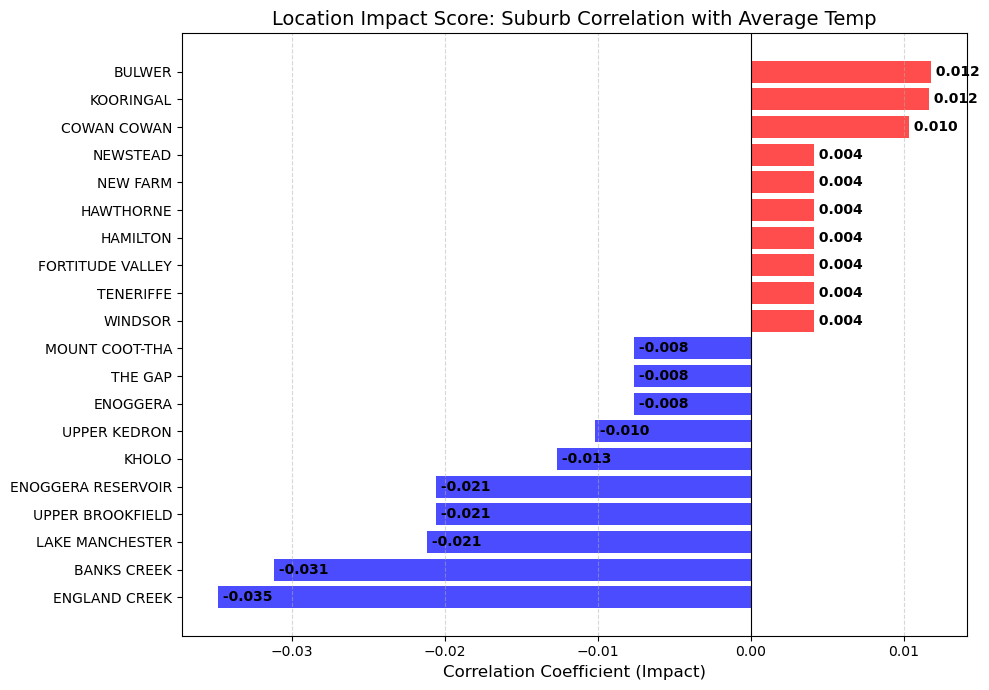

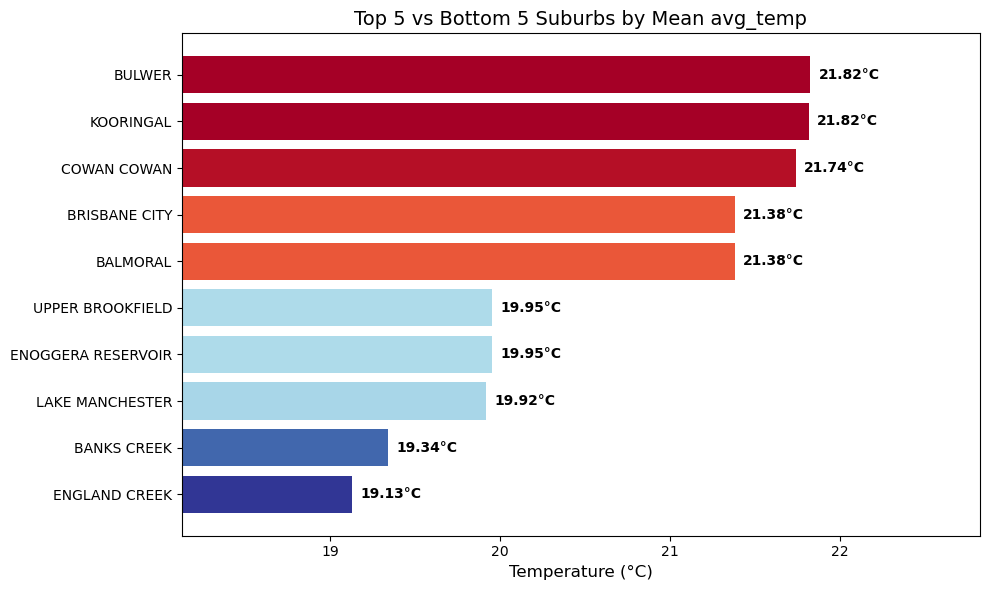

In [155]:
# Finding the over all top 10 highest and Coolest Suburbs; based on heat retention.
# Certain suburbs are geographically in positions where temperature was not too 
# high; however, the overall comfort of people living there is not dictated by 
# how high the peak temperature went, but rather by how much of that heat was retained. 
# Suburbs that recorded high daytime temperatures may also cool faster due to 
# lack of insulation, but those that don't cool faster may be experiencing the 
# 'Urban Heat Island' effect, where concrete and high-density buildings trap 
# thermal energy long after the sun has set.

# Select only the suburb columns and the max_temp
suburb_cols = [col for col in df_encoded.columns if 'suburb_' in col]
target = ['avg_temp']

# Calculate correlation for just these
avg_suburb_impact = df_encoded[suburb_cols + target].corr()['avg_temp'].sort_values(ascending=False)


# Show the correlation plot for top 10 'hottest' and top 10 'coolest' suburbs
avg_title ='Location Impact Score: Suburb Correlation with Average Temp'
plot_correlation(avg_suburb_impact, avg_title)

plot_temps(suburb_cols, df_encoded, target[0])

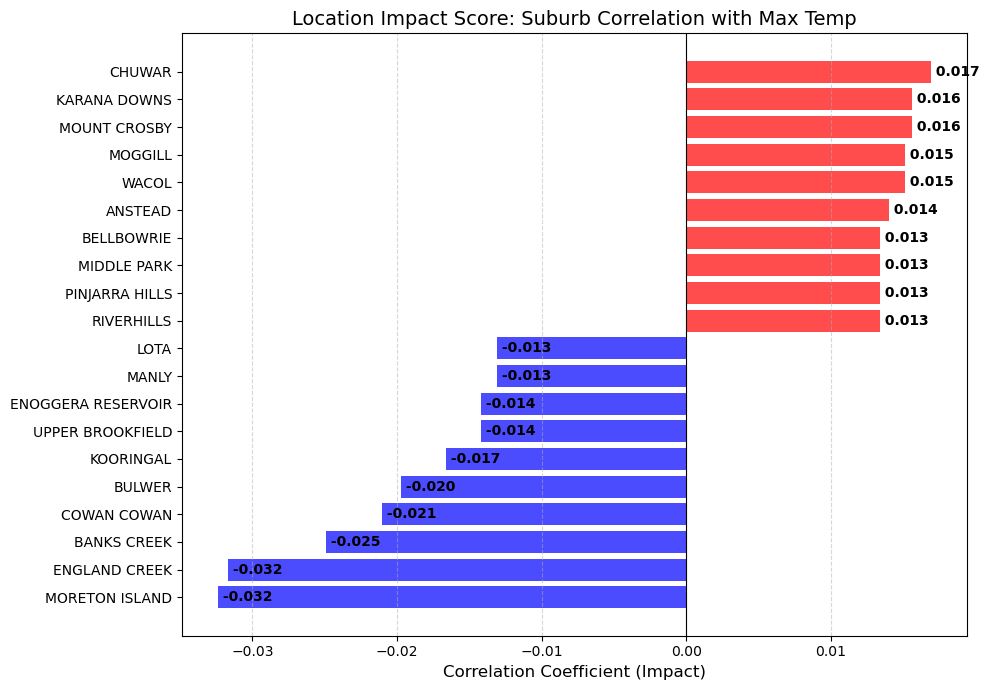

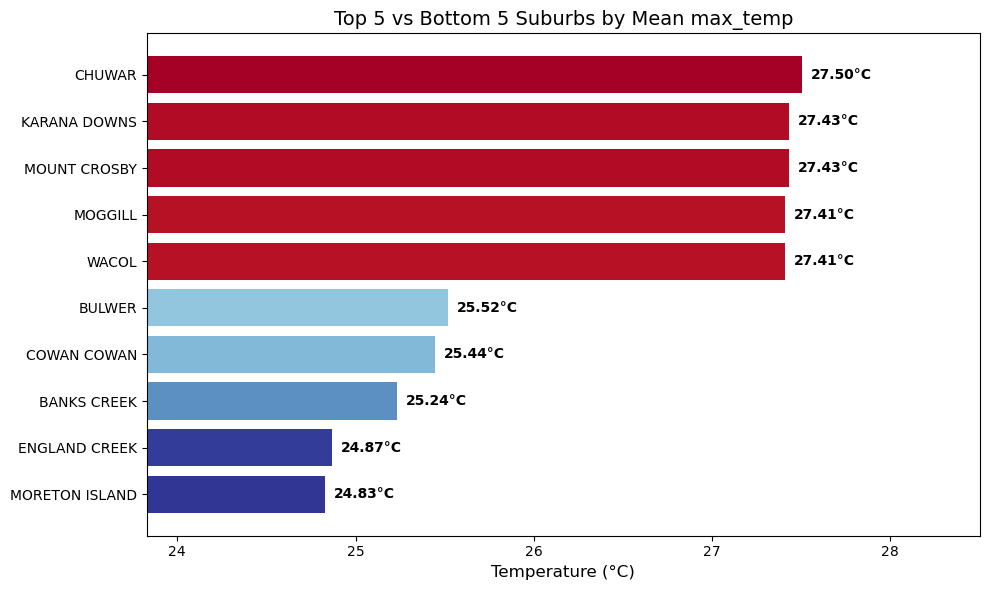

In [156]:
# Select only the suburb columns and the max_temp
suburb_cols = [col for col in df_encoded.columns if 'suburb_' in col]
target = ['max_temp']

# Calculate correlation for just these
max_suburb_impact = df_encoded[suburb_cols + target].corr()['max_temp'].sort_values(ascending=False)

# Show the top 10 'hottest' and top 10 'coolest' suburbs
max_title ='Location Impact Score: Suburb Correlation with Max Temp'
plot_correlation(max_suburb_impact, max_title)

plot_temps(suburb_cols, df_encoded, target_col='max_temp')

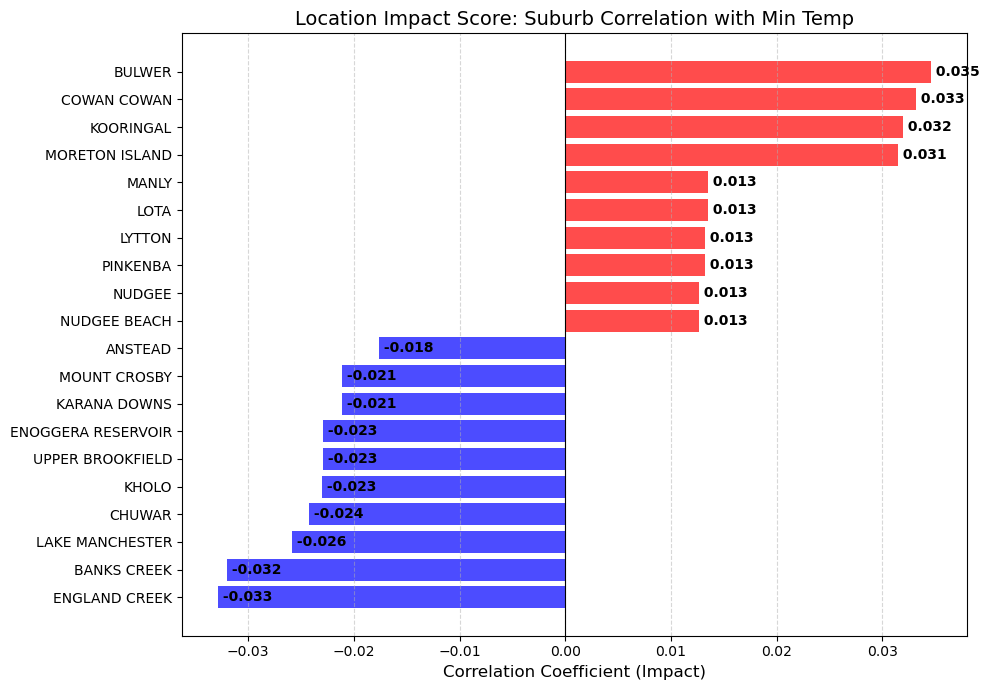

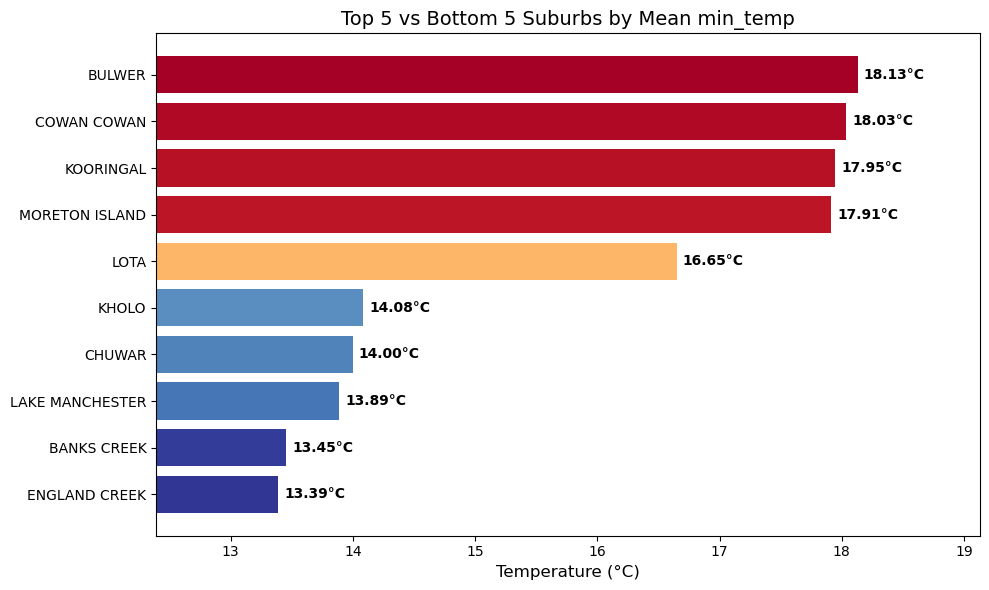

In [157]:
# Select only the suburb columns and the max_temp
suburb_cols = [col for col in df_encoded.columns if 'suburb_' in col]
target = ['min_temp']

# Calculate correlation for just these
min_suburb_impact = df_encoded[suburb_cols + target].corr()['min_temp'].sort_values(ascending=False)

# Show the top 10 'hottest' and top 10 'coolest' suburbs
min_title ='Location Impact Score: Suburb Correlation with Min Temp'
plot_correlation(min_suburb_impact, min_title)

plot_temps(suburb_cols, df_encoded, target_col='min_temp')

In [50]:
# Findings From Above three give us 4 Geographic Climate Profiles or what we can call The Four Brisbanes 

### 1. The Urban and Maritime Thermos
 # Suburbs: Bulwer, Kooringal, Cowan Cowan, Moreton Island, Fortitude Valley, Mt Crosby
 # Thermal Profile: Low-Mod max_temp | High min_temp | High avg_temp
 # Benefit from the High Specific Heat Capacity of the ocean or high thermal mass.
 # Water and dense infrastructure act as a thermal buffer, preventing extreme daytime heat.
 # However, these factors also trap significant thermal warmth overnight (land breeze and sea breeze).

### 2. The Continental Heatlands 
 # Suburbs: Chuwar, Wacol, Taringa, St Lucia, Acacia Ridge
 # Thermal Profile: High max_temp | Low min_temp | High avg_temp
 # Characterized by Low Thermal Inertia and distance from the coast.
 # These areas bake in the sun during the day due to lack of sea breezes.
 # While experience rapid radiative cooling at night, leading to high diurnal volatility.

### 3. The Estuarine Zone 
 # Suburbs: Brisbane Airport, Upper Mt Gravatt, Chandler, Mackenzie
 # Thermal Profile: Moderate max_temp | Moderate min_temp | Moderate avg_temp
 # Transition zones with stable temperatures influenced by bay and river breezes.
 # These areas avoid the extremes of both the inland heat and the urban traps.
 # Represents a balanced climatic profile within the Brisbane region.

### 4. The Cool Sanctuaries 
 # Suburbs: England Creek, Banks Creek, Lake Manchester, Upper Brookfield, Enoggera Reservoir
 # Thermal Profile: Low max_temp | Low min_temp | Low avg_temp
 # Driven by high elevation and dense Green Infrastructure.
 # Canopy cover provides shade and cooling evapotranspiration.
 # These are the overall coolest regions in Greater Brisbane.

In [4]:
sub_array = [
    'ST LUCIA',
    'BULWER', 'KOORINGAL', 
    'CHUWAR', 'MOUNT CROSBY', 
    'FORTITUDE VALLEY', 'BRISBANE AIRPORT', 'CHANDLER' ,
    'ENGLAND CREEK','ENOGGERA RESERVOIR',
]

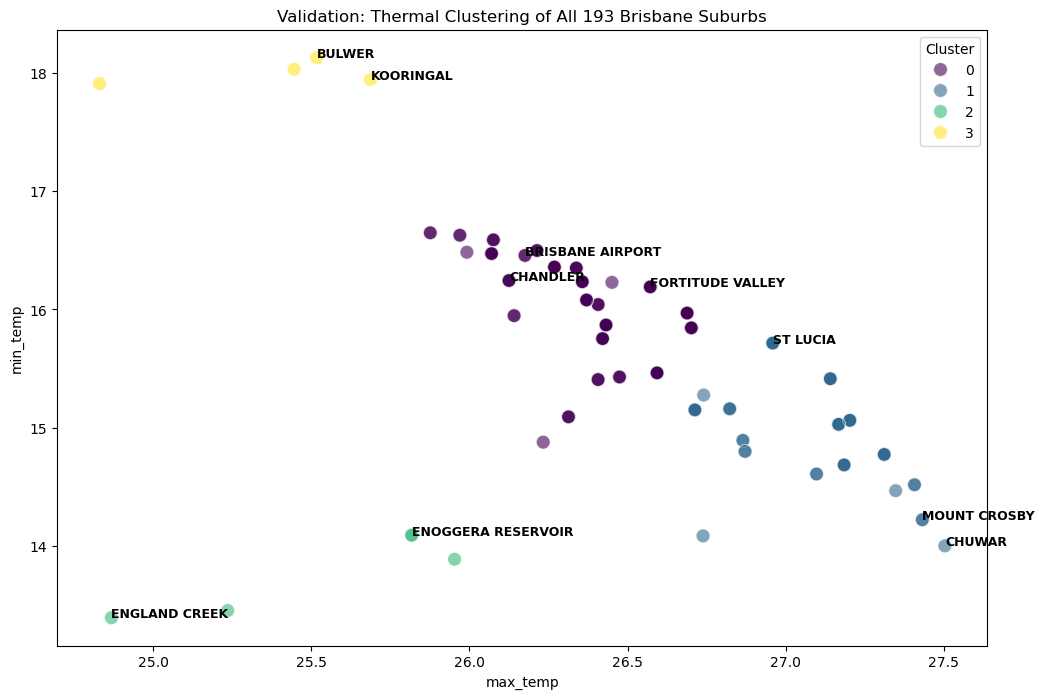

Total suburbs in Cluster 0: 121
['ALBION', 'ALDERLEY', 'ANNERLEY', 'ASCOT', 'ASHGROVE', 'ASPLEY', 'AUCHENFLOWER', 'BALD HILLS', 'BALMORAL', 'BANYO', 'BARDON', 'BELMONT', 'BOONDALL', 'BOWEN HILLS', 'BRACKEN RIDGE', 'BRIDGEMAN DOWNS', 'BRIGHTON', 'BRISBANE AIRPORT', 'BRISBANE CITY', 'BULIMBA', 'BURBANK', 'CAMP HILL', 'CANNON HILL', 'CARINA', 'CARINA HEIGHTS', 'CARINDALE', 'CARSELDINE', 'CHANDLER', 'CHERMSIDE', 'CHERMSIDE WEST', 'CLAYFIELD', 'COOPERS PLAINS', 'COORPAROO', 'DEAGON', 'DUTTON PARK', 'EAGLE FARM', 'EAST BRISBANE', 'EIGHT MILE PLAINS', 'ENOGGERA', 'EVERTON PARK', 'FERNY GROVE', 'FITZGIBBON', 'FORTITUDE VALLEY', 'GAYTHORNE', 'GEEBUNG', 'GORDON PARK', 'GRANGE', 'GREENSLOPES', 'GUMDALE', 'HAMILTON', 'HAWTHORNE', 'HEMMANT', 'HENDRA', 'HERSTON', 'HOLLAND PARK', 'HOLLAND PARK WEST', 'KALINGA', 'KANGAROO POINT', 'KEDRON', 'KELVIN GROVE', 'KEPERRA', 'KURABY', 'LOTA', 'LUTWYCHE', 'LYTTON', 'MACGREGOR', 'MACKENZIE', 'MANLY', 'MANLY WEST', 'MANSFIELD', 'MCDOWALL', 'MILTON', 'MITCHELTON',

In [37]:
# Implementing K mean clustering to confirm the above groups.

# 1. Prepare the feature set by suburb
# We group by suburb to get the 'thermal signature' of each area

# 2. Group all 193 suburbs
full_suburb_features = df.groupby('Suburb').agg({
    'max_temp': 'mean',
    'min_temp': 'mean'
}).reset_index()

# 3. Scale and Cluster
scaler = StandardScaler()
features_scaled = scaler.fit_transform(full_suburb_features[['max_temp', 'min_temp']])
kmeans = KMeans(n_clusters=4, random_state=42)
full_suburb_features['Cluster'] = kmeans.fit_predict(features_scaled)

# 4. Plot with alpha (transparency) to see overlapping suburbs
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=full_suburb_features, 
    x='max_temp', 
    y='min_temp', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,  # This makes overlapping points darker
    s=100
)

# Labeling a few key suburbs from your profiles to see where they land
# This proves the clusters match your "Inland Ovens" vs "Maritime" theory
for i, row in full_suburb_features.iterrows():
    if row['Suburb'] in sub_array:
        plt.annotate(row['Suburb'], (row['max_temp'], row['min_temp']), fontsize=9, fontweight='bold')

plt.title('Validation: Thermal Clustering of All 193 Brisbane Suburbs')
plt.show()

# CHECKING MEMBERS OF EACH CLUSTER
purple_suburbs = full_suburb_features[full_suburb_features['Cluster'] == 0]['Suburb'].tolist()
blue_suburbs = full_suburb_features[full_suburb_features['Cluster'] == 1]['Suburb'].tolist()
yellow_suburbs = full_suburb_features[full_suburb_features['Cluster'] == 3]['Suburb'].tolist()
green_suburbs = full_suburb_features[full_suburb_features['Cluster'] == 2]['Suburb'].tolist()

print(f"Total suburbs in Cluster 0: {len(purple_suburbs)}")
print(purple_suburbs , '\n')

print(f"Total suburbs in Cluster 1: {len(blue_suburbs)}")
print(blue_suburbs, '\n')

print(f"Total suburbs in Cluster 2: {len(green_suburbs)}")
print(green_suburbs, '\n')

print(f"Total suburbs in Cluster 3: {len(yellow_suburbs)}")
print(yellow_suburbs, '\n')


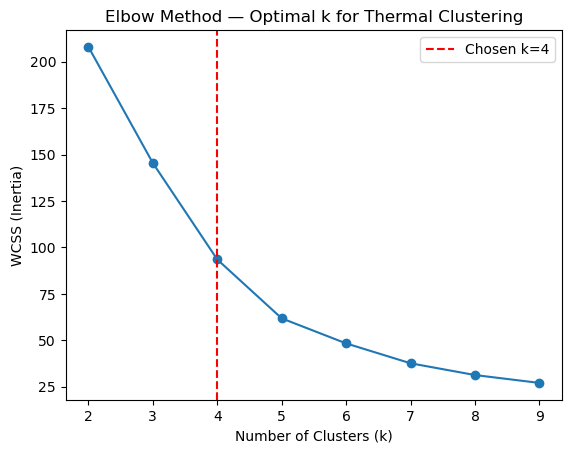

In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use mean max_temp, min_temp (and optionally avg_temp) per suburb
suburb_features = df.groupby('Suburb')[['max_temp', 'min_temp']].mean().reset_index()

X = suburb_features[['max_temp', 'min_temp']]
X_scaled = StandardScaler().fit_transform(X)

wcss = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Optimal k for Thermal Clustering')
plt.axvline(x=4, color='red', linestyle='--', label='Chosen k=4')
plt.legend()
plt.show()

# Jevi

## 1. Suburb Ranking — Hottest & Coldest Suburbs

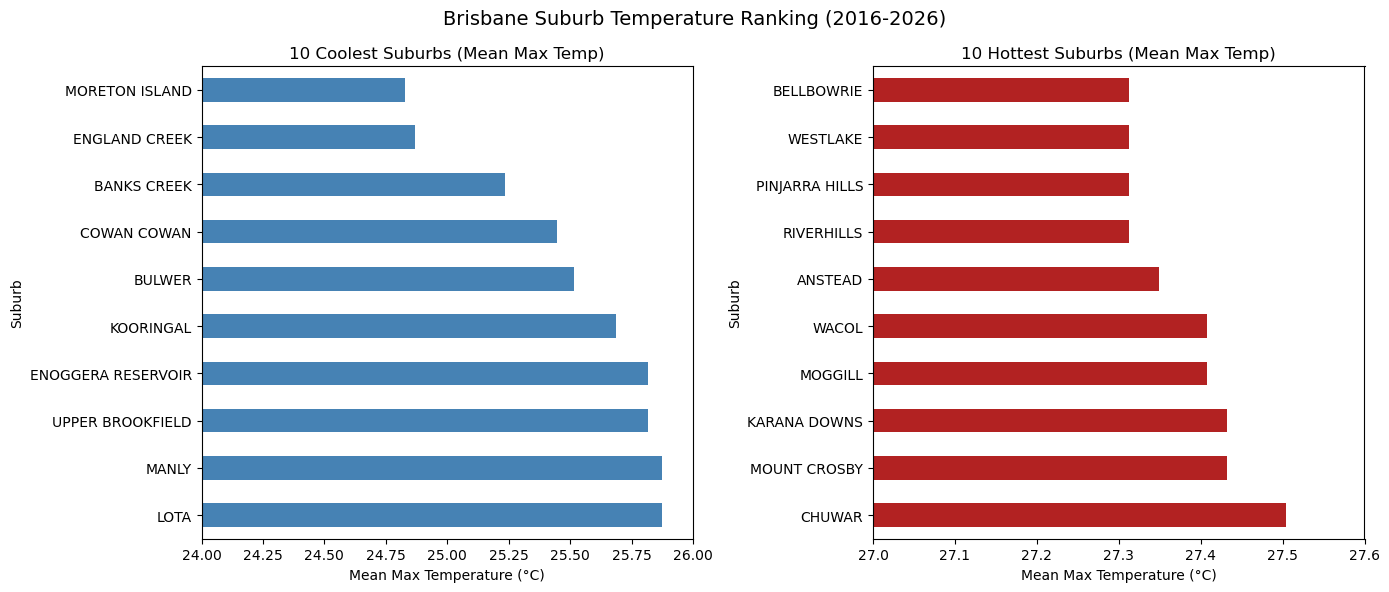

Hottest suburb: CHUWAR (27.50°C)
Coolest suburb: MORETON ISLAND (24.83°C)
Temperature spread across suburbs: 2.68°C


In [143]:
import os
folder_path = "../../"
results_folder = os.path.join(folder_path, "results/q1")
suburb_stats = df.groupby('Suburb')['max_temp'].mean().sort_values()

top_cold = suburb_stats.head(10)
top_hot = suburb_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_cold.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('10 Coolest Suburbs (Mean Max Temp)')
axes[0].set_xlabel('Mean Max Temperature (°C)')
axes[0].set_xlim(24, 26)
axes[0].invert_yaxis()

top_hot.plot(kind='barh', ax=axes[1], color='firebrick')
axes[1].set_title('10 Hottest Suburbs (Mean Max Temp)')
axes[1].set_xlabel('Mean Max Temperature (°C)')
axes[1].set_xlim(27 ,27.6)
axes[1].invert_yaxis()

plt.suptitle('Brisbane Suburb Temperature Ranking (2016-2026)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{results_folder}/Brisbane Suburb Temperature Ranks")
plt.show()

print(f"Hottest suburb: {top_hot.index[-1]} ({top_hot.iloc[-1]:.2f}°C)")
print(f"Coolest suburb: {top_cold.index[0]} ({top_cold.iloc[0]:.2f}°C)")
print(f"Temperature spread across suburbs: {top_hot.iloc[-1] - top_cold.iloc[0]:.2f}°C")

## 2. Spatial Temperature Map

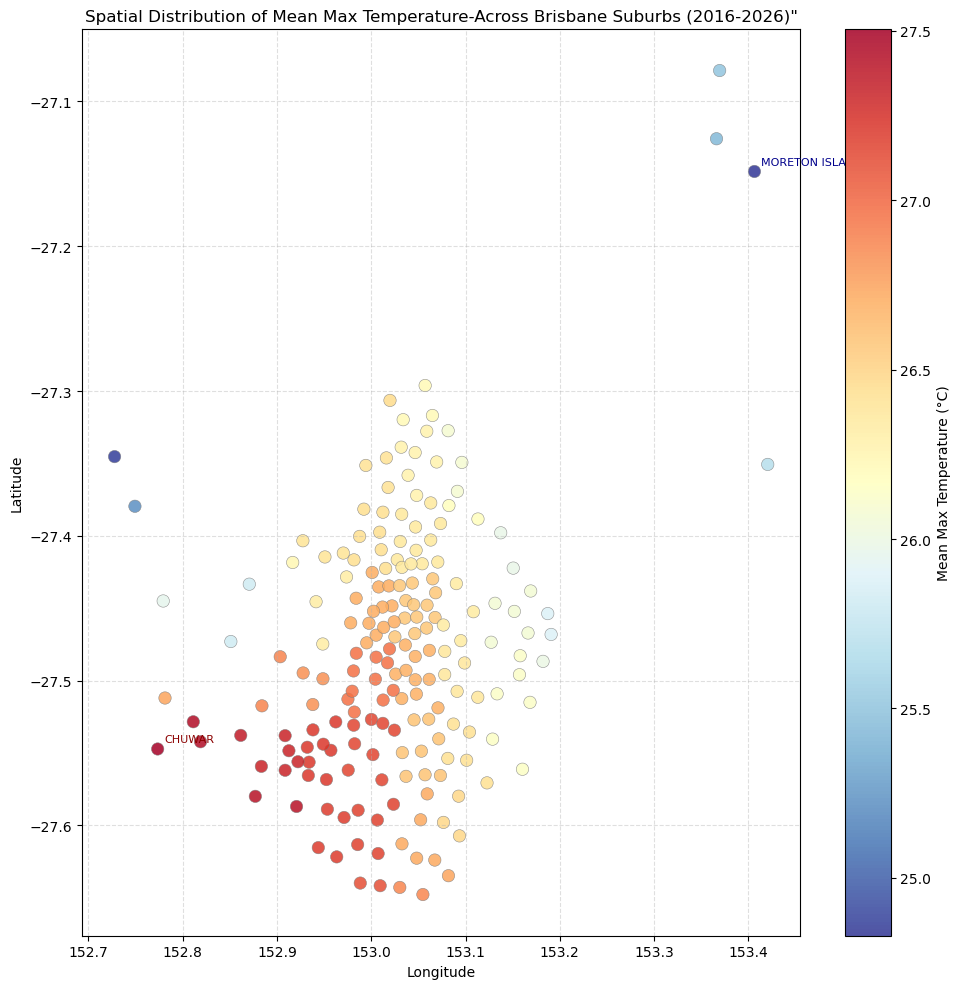

In [33]:
suburb_geo = df.groupby('Suburb').agg(
    mean_max_temp=('max_temp', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index()

plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    suburb_geo['longitude'], suburb_geo['latitude'],
    c=suburb_geo['mean_max_temp'], cmap='RdYlBu_r',
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.4
)
plt.colorbar(scatter, label='Mean Max Temperature (°C)')
plt.title('Spatial Distribution of Mean Max Temperature-Across Brisbane Suburbs (2016-2026)"')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)

hottest = suburb_geo.loc[suburb_geo['mean_max_temp'].idxmax()]
coolest = suburb_geo.loc[suburb_geo['mean_max_temp'].idxmin()]
plt.annotate(hottest['Suburb'], (hottest['longitude'], hottest['latitude']),
             fontsize=8, color='darkred', xytext=(5, 5), textcoords='offset points')
plt.annotate(coolest['Suburb'], (coolest['longitude'], coolest['latitude']),
             fontsize=8, color='darkblue', xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(f"{results_folder}/Spatial Distribution of Mean Max Temp")
plt.show()

## 3. Urban vs Outer Brisbane — Welch's t-Test

C:\Users\jevin\AppData\Local\Temp\ipykernel_18648\549688341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='zone', y='max_temp',


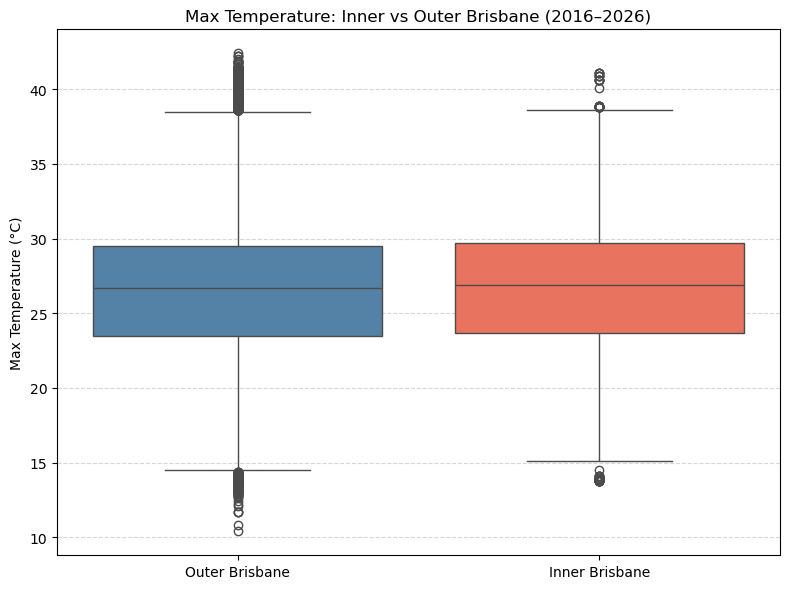

Inner Brisbane mean max temp: 26.70°C
Outer Brisbane mean max temp: 26.58°C
Difference:                   0.12°C
Welch's t-test: t = 7.1169, p = 1.1151e-12
→ Statistically significant difference.


In [25]:
from scipy import stats

inner_suburbs = [
    'ST LUCIA', 'BRISBANE CITY', 'BRISBANE AIRPORT', 'TARINGA', 'TOOWONG',
    'HERSTON', 'SPRING HILL', 'FORTITUDE VALLEY', 'NEW FARM', 'BOWEN HILLS',
    'SOUTH BRISBANE', 'KANGAROO POINT', 'WOOLLOONGABBA', 'PADDINGTON', 'MILTON'
]

df['zone'] = df['Suburb'].apply(lambda s: 'Inner Brisbane' if s in inner_suburbs else 'Outer Brisbane')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='zone', y='max_temp',
            palette={'Inner Brisbane': 'tomato', 'Outer Brisbane': 'steelblue'})
plt.title('Max Temperature: Inner vs Outer Brisbane (2016–2026)')
plt.xlabel('')
plt.ylabel('Max Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{results_folder}/Max Temperature-Inner vs Outer Brisbane (2016-2026)")
plt.show()

inner_temps = df[df['zone'] == 'Inner Brisbane']['max_temp'].dropna()
outer_temps = df[df['zone'] == 'Outer Brisbane']['max_temp'].dropna()

t_stat, p_value = stats.ttest_ind(inner_temps, outer_temps, equal_var=False)
print(f"Inner Brisbane mean max temp: {inner_temps.mean():.2f}°C")
print(f"Outer Brisbane mean max temp: {outer_temps.mean():.2f}°C")
print(f"Difference:                   {inner_temps.mean() - outer_temps.mean():.2f}°C")
print(f"Welch's t-test: t = {t_stat:.4f}, p = {p_value:.4e}")
print("→ Statistically significant difference." if p_value < 0.05 else "→ No statistically significant difference.")

## 4. Temperature Variability by Suburb

NameError: name 'results_folder' is not defined

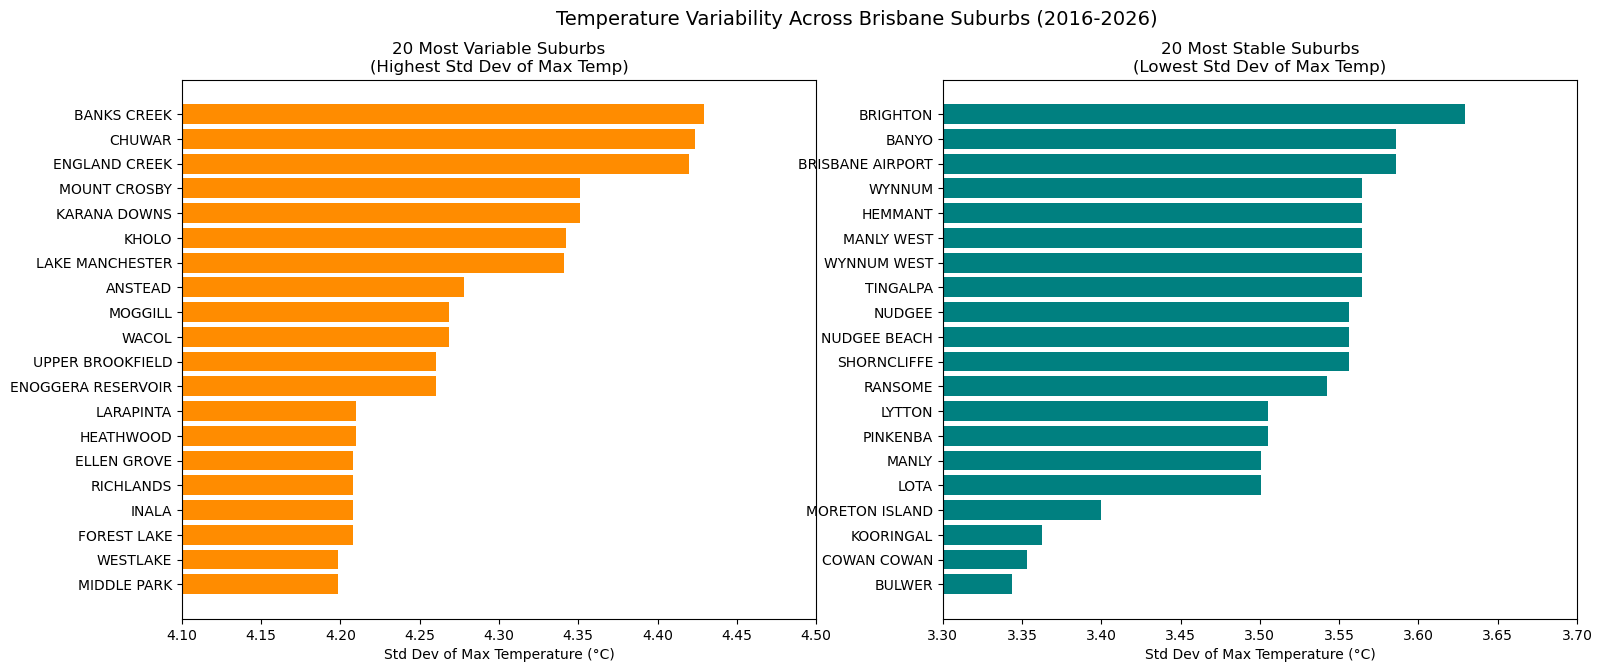

In [133]:
suburb_variability = df.groupby('Suburb')['max_temp'].std().sort_values(ascending=False).reset_index()
suburb_variability.columns = ['Suburb', 'std_max_temp']

top20 = suburb_variability.head(20)
bottom20 = suburb_variability.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top20['Suburb'], top20['std_max_temp'], color='darkorange')
axes[0].set_title('20 Most Variable Suburbs\n(Highest Std Dev of Max Temp)')
axes[0].set_xlabel('Std Dev of Max Temperature (°C)')
axes[0].set_xlim(4.1, 4.5)
axes[0].invert_yaxis()

axes[1].barh(bottom20['Suburb'], bottom20['std_max_temp'], color='teal')
axes[1].set_title('20 Most Stable Suburbs\n(Lowest Std Dev of Max Temp)')
axes[1].set_xlabel('Std Dev of Max Temperature (°C)')
axes[1].set_xlim(3.3, 3.7)
axes[1].invert_yaxis()

plt.suptitle('Temperature Variability Across Brisbane Suburbs (2016-2026)', fontsize=14)
plt.savefig(f"{results_folder}/Temperature Variability Across Brisbane Suburbs (2016-2026)")
plt.tight_layout()
plt.show()

print(suburb_variability['std_max_temp'].describe())

## 5. Temperature vs Latitude — OLS Regression

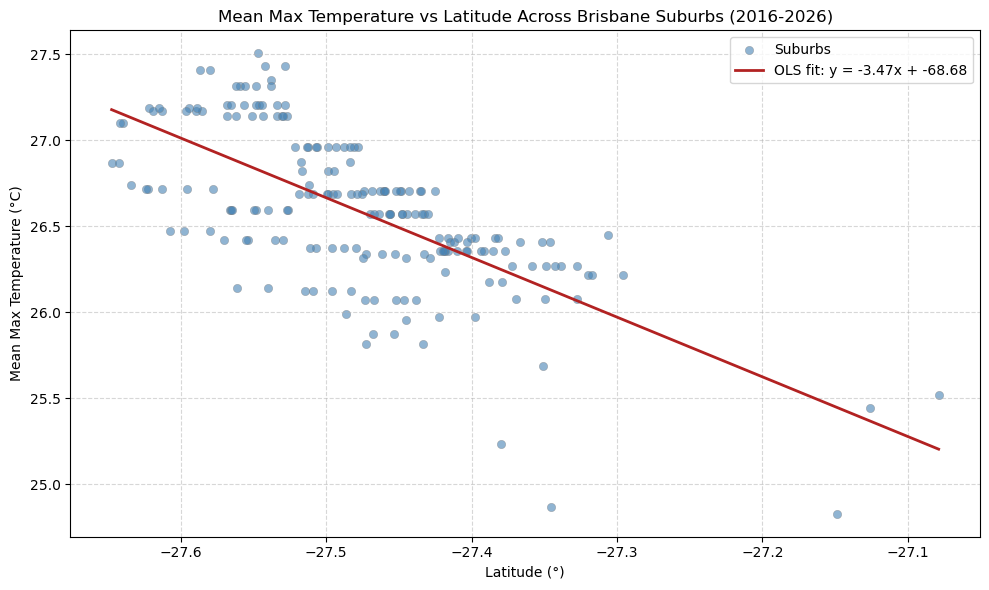

Slope:     -3.4673 °C per degree latitude
R²:        0.4761
p-value:   1.2793e-28
Interpretation: each 1° further south (more negative latitude) changes mean max temp by -3.4673°C


In [34]:
from scipy import stats
import numpy as np

suburb_reg = df.groupby('Suburb').agg(
    mean_max_temp=('max_temp', 'mean'),
    latitude=('latitude', 'first')
).reset_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    suburb_reg['latitude'], suburb_reg['mean_max_temp']
)

x_line = np.linspace(suburb_reg['latitude'].min(), suburb_reg['latitude'].max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 6))
plt.scatter(suburb_reg['latitude'], suburb_reg['mean_max_temp'],
            alpha=0.6, color='steelblue', edgecolors='grey', linewidths=0.4, label='Suburbs')
plt.plot(x_line, y_line, color='firebrick', linewidth=2,
         label=f'OLS fit: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Mean Max Temperature vs Latitude Across Brisbane Suburbs (2016-2026)')
plt.xlabel('Latitude (°)')
plt.ylabel('Mean Max Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{results_folder}/Mean Max Temperature vs Latitude")
plt.show()

print(f"Slope:     {slope:.4f} °C per degree latitude")
print(f"R²:        {r_value**2:.4f}")
print(f"p-value:   {p_value:.4e}")
print(f"Interpretation: each 1° further south (more negative latitude) changes mean max temp by {slope:.4f}°C")